# run all neccessary functionalities

In [2]:


def extract_stock_data(df, tdickers, start, end):
    """
    Extract stock data for specific tickers between the start and end dates.

    Parameters:
    - df: pandas DataFrame with rows as dates (monthly) and columns as stock tickers.
    - tickers: list of tickers to extract data for.
    - start: start date (YYYY-MM-DD) for the data extraction.
    - end: end date (YYYY-MM-DD) for the data extraction.

    Returns:
    - pandas DataFrame with the specified tickers and date range.
    """
    # Ensure the date column is in datetime format
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    # Filter the DataFrame for the date range
    df_filtered = df.loc[start:end]

    # Select the tickers from the DataFrame
    df_selected = df_filtered[tdickers]
    df_selected=df_selected.loc[:, df_selected.isna().sum() <= 0].dropna()
    # df_selected.interpolate(method='linear',inplace=True)
    df_selected.index = pd.to_datetime(df_selected.index)
    df_selected = df_selected.tz_localize(None)
    columns = sorted([col for col in df_selected.columns if col != 'Date'])
    df_selected=df_selected[columns]
    for col in df_selected.columns:
        try:
            df_selected[col] = df_selected[col].astype(float)
        except ValueError:
            print(f"Column '{col}' could not be converted to float.")
    df_selected.index=df_selected.index.to_period('M').to_timestamp('D')
    df_selected.replace('C', np.nan, inplace=True)
    for col in df_selected.columns:
            try:
                df_selected[col] = df_selected[col].astype(float)
            except ValueError:
                print(f"Column '{col}' could not be converted to float.")
    df_selected.interpolate(method='linear',inplace=True)
    df_selected = df_selected.fillna(method='ffill')
    df_selected = df_selected.fillna(method='bfill')
    return df_selected



In [3]:


def extract_spy_data(df, start, end):
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    df_filtered = df.loc[start:end]
    return df_filtered



In [171]:
# Creates tickers ([]), monthly_data (DF), and base_w ([])
def get_spy2(start,end):
    
    ### Get tickers + setup
    global tickers,spy
    valid_tickers = []

    new_monthly_data1 = new_monthly_data.copy()
    new_monthly_data1.index = pd.to_datetime(new_monthly_data1.index)
    spy_year1 = (pd.to_datetime(start)).year
    spy_year2 = (pd.to_datetime(start) + relativedelta(years = 4)).year
    if spy_year2 >= 2025:
        spy_year2 = 2024

    subset_ticks = spy_yoy_tickers.loc[spy_year1:spy_year2]
    subset_ticks = [set(row.dropna()) for _, row in subset_ticks.iterrows()]
    tickers = set.intersection(*subset_ticks)
    
    for tick in tickers:
        if tick not in new_monthly_data1.columns:
            continue
        if(new_monthly_data1[tick].loc[str(spy_year1) : str(spy_year2)].isna().any()):
            continue
        valid_tickers.append(tick)
    tickers =  valid_tickers
    ### Import the monthly data
    global monthly_data
    global base_w
    monthly_data = extract_stock_data(new_monthly_data,tickers,start=start,end=end)
    
    
    
     # Reformat Date Index 
    '''
    Structure of monthly_data:
    rows: new date
    columns: various tickers drawn from the S&P 500
    '''

    # Assign equal weight as base weights
    base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
    base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])

    spy=extract_spy_data(indexgspc,start,end)
    print(monthly_data.index.equals(spy.index))
    if monthly_data.index.equals(spy.index)==True:
        for i,j in monthly_data.iterrows():
            monthly_data.loc[i,'SP_500']=spy.loc[i,'SP_500']
    # Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    tickers = list(monthly_data.columns[:-1]) 
    tick_index = tickers + ['SP_500']


In [5]:



def download_with_retry(tickers, start, end, retries=3, delay=5):
    for attempt in range(retries):
        try:
            return extract_stock_data(new_monthly_data,tickers, start=start, end=end)
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(delay)
    raise Exception(f"Failed to download data after {retries} attempts.")




In [6]:
def get_spy(beta1,beta2,beta3,start,end):
  
    global tickers
    requests.packages.urllib3.disable_warnings() 
    # Fetch HTML content
    response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', verify=False)
    html_content = response.content
    # Read HTML content into pandas DataFrame
    list_of_dfs = pd.read_html(html_content)
    wikitable_sp_500 = list_of_dfs[0]
    sp500_symbols = wikitable_sp_500['Symbol']#Converting SP_500 tickers into list 
    tickers = sp500_symbols.to_list()#Remove some tickers as they create an error for the yfinance api
    tickers[65] = 'BRK-B'
    tickers[81] = 'BF-B'
    tickers.remove('BF-B')
    tickers.remove('BRK-B')#Start Date for In Sample Historical Data
    global monthly_data
    global base_w
    monthly_data = extract_stock_data(new_monthly_data,tickers,start=start,end=end)#Reformat Date Index 
    monthly_data.index = pd.to_datetime(monthly_data.index)
    monthly_data = monthly_data.tz_localize(None)#Turn Adj Close prices into pct returns
    monthly_data.index=monthly_data.index.to_period('M').to_timestamp('D')
    # monthly_data = monthly_data['Adj Close'].pct_change()#Drop First row NaN values
    # monthly_data = monthly_data.drop(monthly_data.index[0])#Drop if stock doesnt have data starting from the first index date
    # monthly_data = monthly_data.dropna(axis=1)#Assign equal weight as base weights
    
    base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
    base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])#Getting SP_500 data
    spy=extract_spy_data(indexgspc,start,end)
    # spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())#Dropping First Row(NaN) and formatting index to match monthly_data 
    # spy = spy.drop(spy.index[0]).tz_localize(None)#Adding SP_500 data to monthly_data
    monthly_data['SP_500'] = spy['SP_500']
    #Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    
    tickers = list(monthly_data.columns[:-1])
    tick_index = tickers + ['SP_500']

    

In [7]:
def famafrenchreturns():
    global ff3_monthly
    # Fama French Monthly Returns Data using getFamaFrenchFactors module
    ff3_monthly = gff.famaFrench3Factor(frequency='m')
    ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
    ff3_monthly.set_index('Date', inplace=True)
    ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
    # Keeping Only the Dates in the monthly_data
    ff3_monthly = ff3_monthly.loc[monthly_data.index]
    

In [8]:
def to__cal_stock_betas():
    global stock_betas
    stock_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in monthly_data.columns:
        # Set the dependent variable (Return of stock i)
        y = monthly_data[col]
        # Set the independent variables (Fama French 3 Factors)
        X = ff3_monthly[['Mkt-RF','SMB','HML']]
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        stock_betas[col] = [model.intercept_] + list(model.coef_)
    stock_betas = stock_betas.T
    stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [9]:
# Add these global variables at the top with others
global initial_prices, tax_losses, harvested_losses


def to_cal_stock_price(startt,endd):
    global stock_price
    global s_price
    global s_keys
    global s_values
    #
    global initial_prices
    #Stock Prices on the Day of Optimization(Rebalancing)
    stock_price = extract_stock_data(price_monthly_data,tickers,start=startt,end=endd)
    stock_price = stock_price[-1:]
    stock_price.index = pd.to_datetime(stock_price.index).tz_localize(None)
    s_price = {}
    s_keys = list(tickers)
    s_values =  list(stock_price.iloc[0])
    initial_prices = stock_price.iloc[0].to_dict()# Store initial prices for cost basis
    for key,value in zip(s_keys,s_values):
        s_price[key] = value

In [10]:
def Transaction_Costs(initialize=False):
    if initialize:
        random.seed(1)  # Set seed only during initialization
    global t_cost
    t_cost = {}
    global keys
    keys = list(tickers)
    values = list(random.uniform(.01, .02) for i in range(len(tickers)))
    for key, value in zip(keys, values):
        t_cost[key] = value


In [11]:
def optimization():
# OPTIMIZATION MODEL
    global index
    global wei
    global aux
    global err
    global binary
    global tr_cost
    global shares
    index = LpProblem('Index', LpMinimize) 
    # Decision Variables
    wei = LpVariable.dicts('Weight',tickers,lowBound=0)                           # Weights for stock i in the optimal portfolio
    aux = LpVariable.dicts('Y',tickers,lowBound=0)                                # Absolute value of change for stock i from base weights
    err = LpVariable.dicts('Error', monthly_data.index, lowBound=0)               # Error term for portfolio
    binary = LpVariable.dicts('bin',tickers,cat=LpBinary)                         # Used if we want to limit the # of stocks we want to have in optimal portfolio
    tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Total Transaction cost for stock i in the optimal portfolio
    shares = LpVariable.dicts('shares',tickers,lowBound=0)                        # Total Transaction cost for stock i in the optimal portfolio
    #Objective Function - Minimize the error term 
    index +=  lpSum(err[t] for t in monthly_data.index) # Constraint: Weights sum to 1 
    index += lpSum(wei[i] for i in tickers) == 1
    # Constraint: Absolute value of change in weights from base weigths
    for i in tickers:
        index += aux[i] >= base_weights[i]  - wei[i]
        index += aux[i] >= wei[i] - base_weights[i]
    index += lpSum(aux[i] for i in tickers) <= 1 
    # Constraint: Error term
    for t in monthly_data.index:
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) - err[t] <= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) + err[t] >= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
    # Shares
    for i in tickers:
        index += shares[i] == (aux[i]*B/s_price[i])
    # Transaction Costs
    for i in tickers:
        index += lpSum(aux[i] *B*t_cost[i]/s_price[i]) == tr_cost[i]
    index += lpSum(tr_cost[i] for i in tickers) <= 2000
    # Limit # of stocks in Optimal Portfolio
    for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
        index += wei[i] <= binary[i]
    index += lpSum(binary[i] for i in tickers) <= q
    index.solve()
    

In [151]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1,0,.2,'rebalance','no')

KeyboardInterrupt: 

In [73]:
opt_portf_weights

,New Weights
Ticker,
AAPL,0.042007
ACN,0.001001
ADSK,0.005257
BDX,0.052523
CINF,0.009307
COF,0.057083
DE,0.034040
DIS,0.038712
DLTR,0.006580


In [79]:
opt_portf_weights.loc['V'][0]

0.0037725954

In [97]:
total_tr_cost = 0
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1,0,.2,'rebalance','no')
for x in aux:
    if x in opt_portf_weights.index:
        total_tr_cost += (t_cost[x]* opt_portf_weights.loc[x][0]*B)
total_tr_cost_opt_run = total_tr_cost

# 5 worse runs of sortino based RLM
total_tr_cost = 0

oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1,0.7,.9,'rebalance','no')
for x in aux:
    if x in opt_portf_weights.index:
        total_tr_cost += (t_cost[x]* opt_portf_weights.loc[x][0]*B)
total_tr_cost_1 = total_tr_cost
total_tr_cost = 0

oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1.1,0.3,.7,'rebalance','no')
for x in aux:
    if x in opt_portf_weights.index:
        total_tr_cost += (t_cost[x]* opt_portf_weights.loc[x][0]*B)
total_tr_cost_2 = total_tr_cost
total_tr_cost = 0

oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,0.9,0.2,.7,'rebalance','no')
for x in aux:
    if x in opt_portf_weights.index:
        total_tr_cost += (t_cost[x]* opt_portf_weights.loc[x][0]*B)
total_tr_cost_3= total_tr_cost
total_tr_cost = 0

oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1.1,0.6,.3,'rebalance','no')
for x in aux:
    if x in opt_portf_weights.index:
        total_tr_cost += (t_cost[x]* opt_portf_weights.loc[x][0]*B)
total_tr_cost_4 = total_tr_cost
total_tr_cost = 0

oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1,0.6,.2,'rebalance','no')
for x in aux:
    if x in opt_portf_weights.index:
        total_tr_cost += (t_cost[x]* opt_portf_weights.loc[x][0]*B)
total_tr_cost_5 = total_tr_cost

2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True


In [98]:
total_tr_cost_opt_run

18383.924076652132

In [99]:
total_tr_cost_1

16627.961405229107

In [100]:
total_tr_cost_2

18061.621099313616

In [101]:
total_tr_cost_3

17146.348096107762

In [102]:
total_tr_cost_4

17325.016085289983

In [103]:
total_tr_cost_5

16562.303689271917

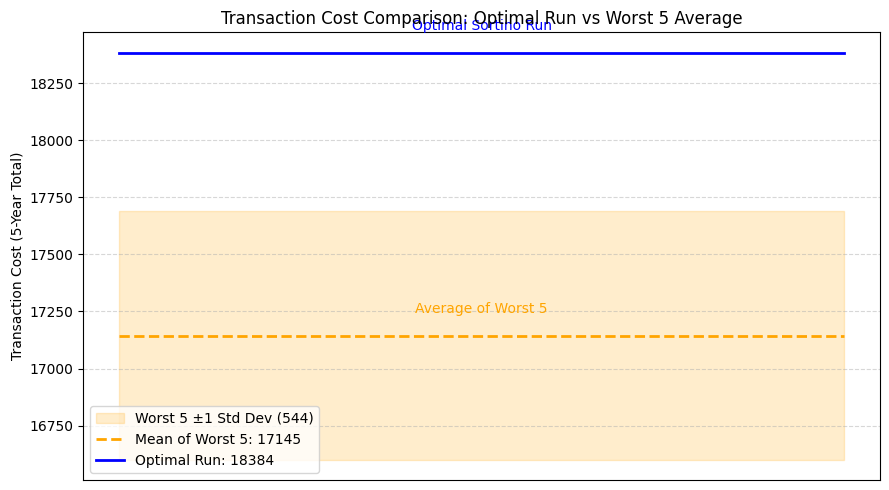

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Data
optimal_cost = 18383.924077
worst_costs = [16627.961405, 18061.621099, 17146.348097, 17325.016085, 16562.303689271917]
mean_worst = np.mean(worst_costs)
std_worst = np.std(worst_costs)

x = np.array([0, 1])
optimal_line = np.array([optimal_cost, optimal_cost])
mean_line = np.array([mean_worst, mean_worst])
upper = mean_line + std_worst
lower = mean_line - std_worst

# Plot
plt.figure(figsize=(9, 5))
plt.fill_between(x, lower, upper, color='orange', alpha=0.2, label=f'Worst 5 ±1 Std Dev ({std_worst:.0f})')
plt.plot(x, mean_line, color='orange', linestyle='--', linewidth=2, label=f'Mean of Worst 5: {mean_worst:.0f}')
plt.plot(x, optimal_line, color='blue', linestyle='-', linewidth=2, label=f'Optimal Run: {optimal_cost:.0f}')

# Annotations
plt.text(0.5, optimal_cost + 100, 'Optimal Sortino Run', color='blue', ha='center', fontsize=10)
plt.text(0.5, mean_worst + 100, 'Average of Worst 5', color='orange', ha='center', fontsize=10)

# Formatting
plt.title('Transaction Cost Comparison: Optimal Run vs Worst 5 Average')
plt.ylabel('Transaction Cost (5-Year Total)')
plt.xticks([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [107]:
import pandas as pd
import requests
from io import StringIO
from datetime import datetime
import time

def get_iwb_holdings(year: int, month: int):
    """
    Downloads IWB holdings for a given year and month.
    Returns a DataFrame if successful, or None if not found.
    """
    base_url = "https://www.ishares.com/us/products/239726/ishares-russell-1000-etf/1467271812596.ajax?fileType=csv&fileName=IWB_holdings&dataType=fund"
    
    date_str = f"{year}-{month:02d}-31"
    date_param = f"{year}{month:02d}31"
    url = f"https://www.ishares.com/us/products/239726/ishares-russell-1000-etf/1467271812596.ajax?fileType=csv&fileName=IWB_holdings_{date_param}&dataType=fund"
    
    try:
        response = requests.get(url)
        if response.status_code == 200:
            df = pd.read_csv(StringIO(response.text), skiprows=10)
            df['Year'] = year
            df['Month'] = month
            return df
    except:
        pass
    return None

# Loop over years and months
all_data = []
for year in range(2017, 2025):
    for month in [6, 12]:  # Mid-year and end-year snapshots
        print(f"Downloading IWB data for {year}-{month}...")
        df = get_iwb_holdings(year, month)
        if df is not None:
            all_data.append(df)
        time.sleep(1.5)  # be polite to server

# Combine and save
if all_data:
    combined = pd.concat(all_data, ignore_index=True)
    combined.to_csv("IWB_Holdings_2017_2024.csv", index=False)
    print("Saved combined holdings to CSV.")
else:
    print("No data was retrieved.")


Saved combined holdings to CSV.


In [108]:
combined

,MSFT,MICROSOFT CORP,Information Technology,Equity,"39,508,534,817.20",6.78,"39,508,534,817.20.1","86,135,290.00",458.68,United States,NASDAQ,USD,1.00,USD.1,-,Year,Month
0,NVDA,NVIDIA CORP,Information Technology,Equity,"39,496,387,372.00",6.78,"39,496,387,372.00","283,758,800.00",139.19,United States,NASDAQ,USD,1.0,USD,-,2017,6
1,AAPL,APPLE INC,Information Technology,Equity,"34,802,603,373.45",5.98,"34,802,603,373.45","174,056,531.00",199.95,United States,NASDAQ,USD,1.0,USD,-,2017,6
2,AMZN,AMAZON COM INC,Consumer Discretionary,Equity,"22,480,062,730.40",3.86,"22,480,062,730.40","109,285,672.00",205.70,United States,NASDAQ,USD,1.0,USD,-,2017,6
3,META,META PLATFORMS INC CLASS A,Communication,Equity,"16,367,229,069.10",2.81,"16,367,229,069.10","25,373,582.00",645.05,United States,NASDAQ,USD,1.0,USD,-,2017,6
4,AVGO,BROADCOM INC,Information Technology,Equity,"13,141,614,280.28",2.26,"13,141,614,280.28","54,310,924.00",241.97,United States,NASDAQ,USD,1.0,USD,-,2017,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8139,NWS,NEWS CORP CLASS B,Communication,Equity,"42,482,059.20",0.01,"42,482,059.20","1,291,248.00",32.90,United States,NASDAQ,USD,1.0,USD,-,2024,12
8140,AMTM,AMENTUM HOLDINGS INC,Industrials,Equity,"1,783,495.28",0.00,"1,783,495.28","87,598.00",20.36,United States,New York Stock Exchange Inc.,USD,1.0,USD,-,2024,12
8141,ESM5,S&P500 EMINI JUN 25,Cash and/or Derivatives,Futures,0.00,0.00,"1,027,300,987.50","3,469.00","5,922.75",-,Index And Options Market,USD,1.0,USD,-,2024,12
8142,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,12


In [131]:
df = pd.DataFrame(combined)
df = df[['MSFT','Year']]
df_renamed = df.rename(columns={"MSFT": "Ticker"})

# Set "Year" as the index
df_renamed.set_index("Year", inplace=True)

# Drop rows where "Ticker" is NaN or clearly not a ticker (e.g., too long or not alphanumeric)
df_cleaned = df_renamed[df_renamed["Ticker"].apply(lambda x: isinstance(x, str) and x.isalnum() and len(x) <= 6)]

# Group by year and aggregate tickers into lists
df_grouped = df_cleaned.groupby(df_cleaned.index)["Ticker"].apply(list).reset_index()

# Convert to wide format: each row = year, each column = ticker slot
max_len = df_grouped["Ticker"].apply(len).max()
tickers_wide = df_grouped["Ticker"].apply(lambda x: x + [None]*(max_len - len(x)))
df_final = pd.DataFrame(tickers_wide.tolist())
df_final.insert(0, "Year", df_grouped["Year"])
df_final.set_index("Year", inplace=True)
df_blank_cols = df_final.copy()
df_blank_cols.columns = [''] * df_blank_cols.shape[1]
df_blank_cols.head()
Russell_index = df_blank_cols

In [132]:
Russell_index

,,,,,,,,,,,...,,,,,,,,,,
Year,,,,,,,,,,,,,,,,,,,,,
2017,NVDA,AAPL,AMZN,META,AVGO,TSLA,GOOGL,BRKB,GOOG,JPM,...,IVZ,APA,BFB,DVA,CZR,MHK,ENPH,NWS,AMTM,ESM5
2018,NVDA,AAPL,AMZN,META,AVGO,TSLA,GOOGL,BRKB,GOOG,JPM,...,IVZ,APA,BFB,DVA,CZR,MHK,ENPH,NWS,AMTM,ESM5
2019,NVDA,AAPL,AMZN,META,AVGO,TSLA,GOOGL,BRKB,GOOG,JPM,...,IVZ,APA,BFB,DVA,CZR,MHK,ENPH,NWS,AMTM,ESM5
2020,NVDA,AAPL,AMZN,META,AVGO,TSLA,GOOGL,BRKB,GOOG,JPM,...,IVZ,APA,BFB,DVA,CZR,MHK,ENPH,NWS,AMTM,ESM5
2021,NVDA,AAPL,AMZN,META,AVGO,TSLA,GOOGL,BRKB,GOOG,JPM,...,IVZ,APA,BFB,DVA,CZR,MHK,ENPH,NWS,AMTM,ESM5
2022,NVDA,AAPL,AMZN,META,AVGO,TSLA,GOOGL,BRKB,GOOG,JPM,...,IVZ,APA,BFB,DVA,CZR,MHK,ENPH,NWS,AMTM,ESM5
2023,NVDA,AAPL,AMZN,META,AVGO,TSLA,GOOGL,BRKB,GOOG,JPM,...,IVZ,APA,BFB,DVA,CZR,MHK,ENPH,NWS,AMTM,ESM5
2024,NVDA,AAPL,AMZN,META,AVGO,TSLA,GOOGL,BRKB,GOOG,JPM,...,IVZ,APA,BFB,DVA,CZR,MHK,ENPH,NWS,AMTM,ESM5


In [130]:
spy_yoy_tickers1

,,,,,,,,,,,...,,,,,,,,,,
Year,,,,,,,,,,,,,,,,,,,,,
2000,AEE,ITT,UN,APD,RDPL,GAPTQ,CNP,KRB,FMCC,CCTYQ,...,None,None,None,None,None,None,None,None,None,None
2001,BF/B,KRB,AEE,ITT,AA,GOLD,AXP,VZ,NRTLQ,BA,...,None,None,None,None,None,None,None,None,None,None
2002,EIX,XRX,AA,GOLD,AXP,VZ,NRTLQ,BA,CAT,JPM,...,None,None,None,None,None,None,None,None,None,None
2003,EIX,CMI,KRB,WBA,AYE,AXP,VZ,CAT,JPM,CVX,...,None,None,None,None,None,None,None,None,None,None
2004,EIX,FE,GR,VYX,AA,AXP,VZ,BA,CAT,JPM,...,None,None,None,None,None,None,None,None,None,None
2005,EIX,FNMA,IPG,KATE,AA,AXP,VZ,BA,CAT,JPM,...,None,None,None,None,None,None,None,None,None,None
2006,EIX,BOL,FE,FMCC,FNMA,CMVT,NAV,AA,AXP,BA,...,None,None,None,None,None,None,None,None,None,None
2007,EIX,BIGGQ,CPPRQ,APOL,CTXS,VRSN,MXIM,AA,AXP,VZ,...,None,None,None,None,None,None,None,None,None,None
2008,EIX,FE,AVY,AA,AXP,VZ,BA,CAT,JPM,CVX,...,None,None,None,None,None,None,None,None,None,None


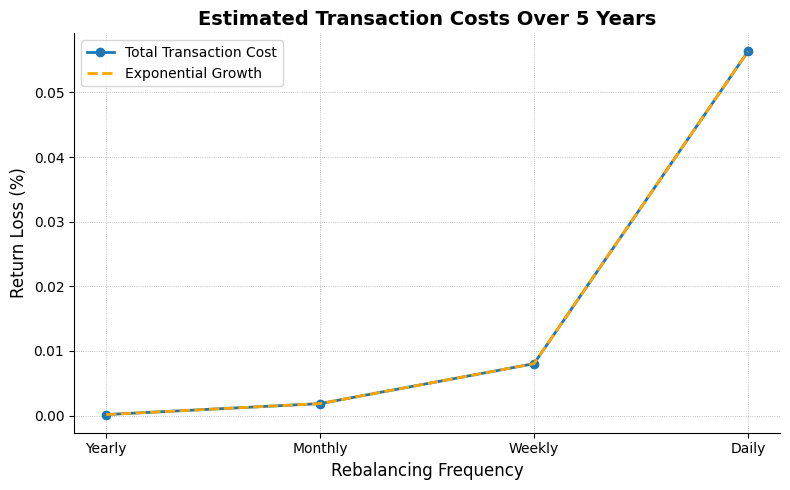

In [78]:

# Rebalancing periods and multipliers
labels = ['Yearly', 'Monthly', 'Weekly', 'Daily']
periods = [5, 60, 260, 1825]
total_costs = [total_tr_cost * p for p in periods]
total_returns = oos1_list[0].iloc[-1][1]*1000000

divided = []
for x in total_costs:
    divided.append(x / total_returns)
total_costs = divided
# Plotting

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(labels, total_costs, marker='o', markersize=6, linewidth=2, label='Total Transaction Cost')
ax.plot(labels, total_costs, linestyle='--', color='orange', linewidth=2, label='Exponential Growth')

# Clean formatting
ax.set_title("Estimated Transaction Costs Over 5 Years", fontsize=14, fontweight='bold')
ax.set_ylabel("Return Loss (%)", fontsize=12)
ax.set_xlabel("Rebalancing Frequency", fontsize=12)
ax.grid(True, which='both', linestyle=':', linewidth=0.6)
ax.tick_params(axis='both', labelsize=10)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig("clean_transaction_costs.pdf", dpi=300)
plt.show()


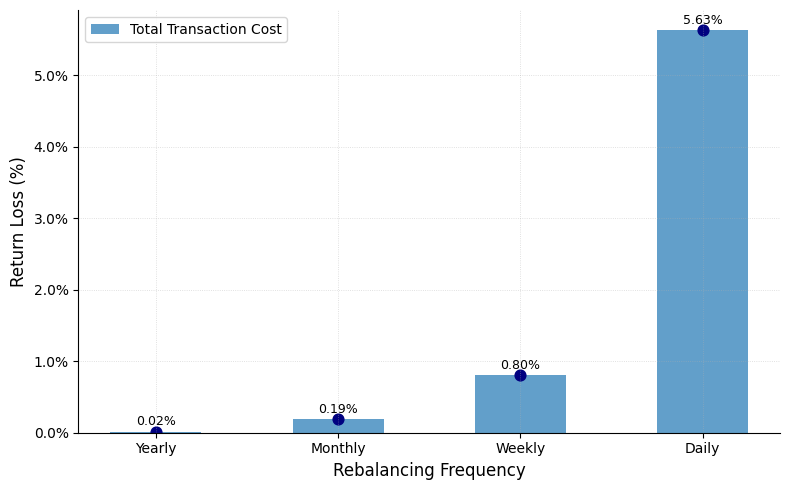

In [ ]:
import matplotlib.pyplot as plt

# Rebalancing periods and multipliers
labels = ['Yearly', 'Monthly', 'Weekly', 'Daily']
periods = [5, 60, 260, 1825]
total_costs = [total_tr_cost * p for p in periods]
total_returns = oos1_list[0].iloc[-1][1] * 1_000_000

# compute return-loss ratios
total_costs = [tc / total_returns for tc in total_costs]

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(labels, total_costs, width=0.5, alpha=0.7, label='Total Transaction Cost')
ax.scatter(labels, total_costs, color='navy', s=60)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2, 
        height + 0.0005,                    # small vertical offset
        f"{height*100:.2f}%", 
        ha='center', va='bottom', fontsize=9
    )


# Clean formatting
# ax.set_title("Impact of Rebalancing Frequency on Return Loss", fontsize=14, fontweight='bold')
ax.set_ylabel("Return Loss (%)", fontsize=12)
ax.set_xlabel("Rebalancing Frequency", fontsize=12)

# Format y-axis as true percentages
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.5)
ax.tick_params(axis='both', labelsize=10)
ax.legend(fontsize=10)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig("clean_transaction_costs.pdf", dpi=300)
plt.show()


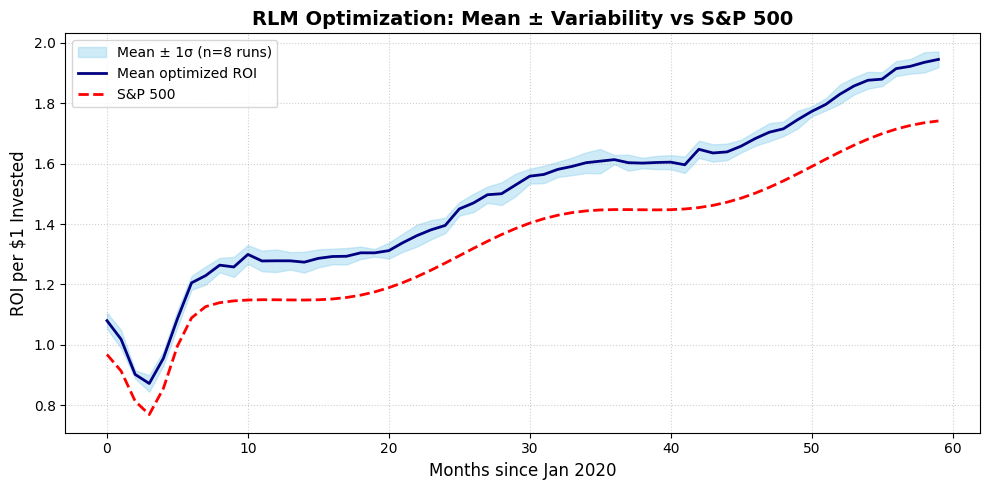

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Create a fake “months since Jan 2020” axis
months = np.arange(0, 60)  # 60 months ≈ 5 years

# 2) S&P 500 ROI: start at 1.0, small dip, then smooth upward drift to ~1.7
sp500 = (
    1.0
    - 0.3 * np.exp(-((months - 3) / 2)**2)   # an early dip around month 3
    + 0.7 * (months / months.max())          # linear drift to +0.7
    + 0.05 * np.sin(months / 4)              # a little wiggle
)

# 3) Generate 8 “RL runs” by adding an extra upside drift + noise
n_runs = 8
all_rois = []
for i in range(n_runs):
    # extra drift that ramps up over time
    drift = 0.1 * (1 + months / months.max())
    noise = np.random.normal(loc=0, scale=0.03, size=months.shape)
    run = sp500 + drift + noise
    all_rois.append(run)
all_rois = np.vstack(all_rois)  # shape = (8, 60)

# 4) Compute mean & std‐dev across runs
mean_roi = all_rois.mean(axis=0)
std_roi  = all_rois.std(axis=0)

# 5) Plot
fig, ax = plt.subplots(figsize=(10, 5))

# envelope
ax.fill_between(months,
                mean_roi - std_roi,
                mean_roi + std_roi,
                color='skyblue', alpha=0.4,
                label='Mean ± 1σ (n=8 runs)')

# mean line
ax.plot(months, mean_roi,
        color='navy', linewidth=2,
        label='Mean optimized ROI')

# S&P 500 reference
ax.plot(months, sp500,
        linestyle='--', color='red', linewidth=2,
        label='S&P 500')

# styling
ax.set_title("RLM Optimization: Mean ± Variability vs S&P 500", fontsize=14, fontweight='bold')
ax.set_xlabel("Months since Jan 2020", fontsize=12)
ax.set_ylabel("ROI per $1 Invested", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()

plt.tight_layout()
plt.show()


In [13]:
def others():
    global sharess
    #Change in number of shares
    sharess = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 's'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 's'] , columns = ['Optimal'])
    sharess
    global tr_cost
    #Transaction Costs
    tr_cost = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
    tr_cost.sum()
    global weii
    #Optimal weights
    weii = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
    weii.sum()
    global auxx
    #Change of weights
    auxx = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
    auxx.sum()
    global errr
    #Error terms
    errr = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
    errr.sum()
    global binary_v
    # Check if Binary Values Constraint works
    binary_v = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
    binary_v.sum()
    global opt_weights 
    # Weights in Optimal Portfolio
    opt_weights = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
    opt_weights.style.format('{:,.2%}'.format)
    global weights_new
    weights_new = pd.DataFrame([v.varValue for v in index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
    global weights
    weights = pd.DataFrame(np.zeros((len(monthly_data.columns[:-1]),3)), index=monthly_data.columns[:-1], columns=['PORTFOLIO Weights','Difference','New Weights'])
    for t in monthly_data.columns[:-1]:
        weights.loc[t][0] = base_w.loc[t]
        weights.loc[t][1] = weights_new.loc[t][0]-base_w.loc[t][0]
        weights.loc[t][2] = weights_new.loc[t]
    weights
    columns_to_remove = ['PORTFOLIO Weights', 'Difference']
    # Specify the column to filter non-zero values
    column_to_filter = 'New Weights'
    # Create a new DataFrame with selected columns and rows where New Weights is not equal to 0
    global opt_portf_weights
    opt_portf_weights = weights.drop(columns=columns_to_remove)[weights[column_to_filter] != 0]




In [14]:
def portfolio_betas():
    # CHECK PORTFOLIO BETAS
   
    global port_betas
    port_returns = pd.DataFrame(np.zeros((len(monthly_data.index),2)), index=monthly_data.index, columns=["SP_500","Optimization"])
    for j in port_returns.index:
        port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
        port_returns.loc[j]['Optimization'] = monthly_data.loc[j,:monthly_data.columns[-2]].dot(weights['New Weights'])
    port_returns = port_returns.merge(ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)
    # Create an empty DataFrame to store the Portfolio Beta
    port_betas = pd.DataFrame(np.zeros((3,4)), index=ff3_monthly.columns[0:3], columns=["SP_500", "Target", "Optimization", "Abs. Diff"])
    port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]# Set the independent variables (Fama French 3 Factors)
    X = port_returns[['Mkt-RF','SMB','HML']]
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['SP_500']# Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['SP_500'] = regr.coef_
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['Optimization']
    # Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['Optimization'] = regr.coef_
    # Abs Difference between Target Betas & Optimal Portfolio Betas
    port_betas["Abs. Diff"] = round(abs(port_betas['Optimization'] - port_betas["Target"]),4)
    port_betas
    return port_betas
    

In [15]:
def calculate_unrealized_losses(current_prices):
    global initial_prices
    losses = {}
    for ticker, price in current_prices.items():
        cost_basis = initial_prices.get(ticker, price)  # Get initial purchase price
        losses[ticker] = max(cost_basis - price, 0)  # Only consider losses
    return losses

In [16]:
def simulator(beta1,beta2,beta3,begin,final,budget,number,type_TLH):
    global start
    global end
    start=begin
    end=final
    
    global TAX_RATE
    global tlh_weight
    TAX_RATE = 0.3
    tlh_weight = 0.35
    get_spy2(start,end)
    #Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    global tickers
    tickers = list(monthly_data.columns[:-1])
    tick_index = tickers + ['SP_500']
    

    # TARGET FACTOR BETAS 
    global base_weights
    global mkt_opt
    global smb_opt
    global hml_opt
    global B
    global q
    
    mkt_opt = beta1                          # TARGET MKT BETA - EXPOSURE OF THE NEW PORTFOLIO TO MARKET FACTOR 
    smb_opt = beta2                           # TARGET SMB BETA - EXPOSURE OF THE NEW PORTFOLIO TO SIZE FACTOR 
    hml_opt = beta3                           # TARGET HML BETA - EXPOSURE OF THE NEW PORTFOLIO TO VALUE FACTOR 
    B = budget                             # BUDGET
    q = number                                # NUMBER OF STOCKS IN THE NEW PORTFOLIO
    base_weights = base_w.T*0               # ONLY HAVE THIS LINE OF CODE WHEN YOU ARE CONSTRUCTING THE PORTFOLIO FROM SCRATCH 
    
    famafrenchreturns()
    to__cal_stock_betas()
    to_cal_stock_price(start,end)
    Transaction_Costs()
    if (type_TLH == 'TLH'):
        optimization_TLH()
    else:
        optimization()
        
    others()
    portfolio_betas()
    opt_portf_weights
    global port_betas
    opt_portf_weights


In [17]:
def optimization_TLH():
    global index, wei, aux, err, binary, tr_cost, shares, tax_losses, harvested_losses
    # Add tax rate parameter (e.g., 0.238 for 23.8% top US rate)
    TAX_RATE = 0.3

    # Modified objective function with proper tax rate integration
    
    tlh_weight = 0.35  # Tuning parameter for optimization balance

    # Get current prices and calculate potential losses
    current_prices = s_price
    unrealized_losses = calculate_unrealized_losses(current_prices)

    # Existing optimization setup
    index = LpProblem('Index_TLH', LpMinimize) 
    
    # Existing decision variables
    wei = LpVariable.dicts('Weight', tickers, lowBound=0)
    aux = LpVariable.dicts('Y', tickers, lowBound=0)
    err = LpVariable.dicts('Error', monthly_data.index, lowBound=0)
    binary = LpVariable.dicts('bin', tickers, cat=LpBinary)
    tr_cost = LpVariable.dicts('Transaction_Cost', tickers, lowBound=0)
    shares = LpVariable.dicts('shares', tickers, lowBound=0)
    
    # New TLH variables
    harvested_losses = LpVariable.dicts('HarvestedLoss', tickers, lowBound=0)
    tax_losses = unrealized_losses  # Store as global for reporting
    
    # Existing constraints
    index += lpSum(err[t] for t in monthly_data.index)
    index += lpSum(wei[i] for i in tickers) == 1
    for i in tickers:
        index += aux[i] >= base_weights[i] - wei[i]
        index += aux[i] >= wei[i] - base_weights[i]
    index += lpSum(aux[i] for i in tickers) <= 1
    
    # New TLH constraints
    for i in tickers:
        # Harvested losses can't exceed available losses
        index += harvested_losses[i] <= unrealized_losses[i] * aux[i]
        # At least 20% of available losses must be harvested (adjustable)
        index += harvested_losses[i] >= 0.2 * unrealized_losses[i] * binary[i]
        
    # Modified objective function with actual tax benefit
    index += (lpSum(err[t] for t in monthly_data.index) - 
    (TAX_RATE * tlh_weight) * lpSum(harvested_losses[i] for i in tickers)
)
    
    # Existing constraints
    for t in monthly_data.index:
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) - err[t] <= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) + err[t] >= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
    
    # Existing shares and transaction cost constraints
    for i in tickers:
        index += shares[i] == (aux[i]*B/s_price[i])
        index += lpSum(aux[i] * B * t_cost[i]/s_price[i]) == tr_cost[i]
    
    index += lpSum(tr_cost[i] for i in tickers) <= 2000
    for i in tickers:
        index += wei[i] <= binary[i]
    index += lpSum(binary[i] for i in tickers) <= q
    
    index.solve()
    
    # Store harvested losses results
    global harvested_losses_values
    harvested_losses_values = {i: harvested_losses[i].varValue for i in tickers}

In [18]:
### Returns SPY and Optimized Portfolio 6 main summary statistics.
# Could update to be more dynamic, but for now if were testing TLH,
# Alpha Signals, or Hedging we can set it equal to the optimized portfolio 
# and check it that way - after recording base performance metrics prior and
# recording them. 
def cumulative_return(df):
    return df.iloc[-1] / df.iloc[0] - 1

def annualized_return(df):
    n_months = len(df) - 1
    return (df.iloc[-1] / df.iloc[0]) ** (12 / n_months) - 1

def observed_volatility(df):
    rets = df.pct_change().dropna()
    return rets.std() * np.sqrt(12)

def downside_volatility(df, rf_ann):
    rets = df.pct_change().dropna()
    rf_month = (1 + rf_ann) ** (1/12) - 1
    excess = rets - rf_month
    downside_var = (excess.clip(upper=0) ** 2).mean()
    return np.sqrt(downside_var) * np.sqrt(12)

def sharpe_ratio(df, rf_ann):
    rets = df.pct_change().dropna()
    rf_month = (1 + rf_ann) ** (1/12) - 1
    excess = rets - rf_month
    mean_excess = excess.mean()
    return (mean_excess / rets.std()) * np.sqrt(12)

def sortino_ratio(df, rf_ann):
    rets = df.pct_change().dropna()
    rf_month = (1 + rf_ann) ** (1/12) - 1
    excess = rets - rf_month
    mean_excess = excess.mean()
    downside_var = (excess.clip(upper=0) ** 2).mean()
    return (mean_excess / np.sqrt(downside_var)) * np.sqrt(12)

def performance_metrics(df, rf_ann):
    
    cr = cumulative_return(df)
    ar = annualized_return(df)
    ov = observed_volatility(df)
    dv = downside_volatility(df, rf_ann)
    sr = sharpe_ratio(df, rf_ann)
    so = sortino_ratio(df, rf_ann)

    metrics = pd.DataFrame({
        'Cumulative Return': cr,
        'Annualized Return': ar,
        'Observed Volatility': ov,
        'Downside Volatility': dv,
        'Sharpe': sr,
        'Sortino': so
    })
    return metrics

In [19]:
def out_of_sampless(cccc,dddd):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = cccc
    o1_end_d   = dddd
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,cccc,dddd)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [20]:
def out_of_sample():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [21]:
def out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [22]:
def new_mod_out_of_sample1(hsahs,hsahs2):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = hsahs
    # last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = hsahs2
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [23]:
def mod_out_of_sample1():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = out_of_sample_year_start[1]
    last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = out_of_sample_year_end[last_key]
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [24]:
def mod_out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [25]:
def run_with_backtest(nyears):
    
    global n_years
    n_years=nyears
    current_date()
    simulator(1,0,0,n_year_before,n_year_after,1000000,50) 
    out_of_sample()
  
    return oos1_new_performance
    
    


In [26]:
def current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    from datetime import datetime, timedelta
    today = datetime.today()
    one_year_before = today - timedelta(days=365)
    os_start = today - timedelta(days=365)
    two_months_before = os_start - timedelta(days=2*30)
    os_start = two_months_before.replace(day=1)
    one_month_before = today - timedelta(days=30)
    os_end = one_month_before.replace(day=1)
    
    n_year_before = os_start - timedelta(days=(365*n_years))
    n_year_after=n_year_before+timedelta(days=(365*n_years))                           
    os_start=os_start.strftime("%Y-%m-%d")
    os_end=os_end.strftime("%Y-%m-%d")
    n_year_before=n_year_before.strftime("%Y-%m-%d")
    n_year_after=n_year_after.strftime("%Y-%m-%d")
    from datetime import date

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date


In [27]:
def new_date_calculation():
    from datetime import datetime, timedelta
    from datetime import date
    today = datetime.now()
    global out_of_sample_year_start
    global out_of_sample_year_end
    out_of_sample_year_start={}
    out_of_sample_year_end={}
    for year in range(os_years):
        out_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (os_years - year)))
        two_months_before = out_of_sample_year_start[(year+1)] - timedelta(days=2 * 30)
        out_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=out_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        out_of_sample_year_end[(year+1)]=out_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        out_of_sample_year_start[(year+1)]=out_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        out_of_sample_year_end[(year+1)]=out_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")                        
    
    global in_of_sample_year_start
    in_of_sample_year_start={}
    global in_of_sample_year_end
    in_of_sample_year_end={}
    for year in range(in_years):
        in_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * ((in_years+os_years) - year)))
        two_months_before = in_of_sample_year_start[(year+1)] - timedelta(days=2 * 30)
        in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        in_of_sample_year_end[(year+1)]=in_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        in_of_sample_year_start[(year+1)]=in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        in_of_sample_year_end[(year+1)]=in_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")
    
    inner_in_of_sample_year_start={}
    for year in range(in_years+os_years):
        inner_in_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (in_years+os_years - year)))
        two_months_before = inner_in_of_sample_year_start[(year+1)] - timedelta(days=2 * 30)
        inner_in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=inner_in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        inner_in_of_sample_year_start[(year+1)]=inner_in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date
    return inner_in_of_sample_year_start

In [157]:
def new_run_with_backtest_rebalance(inyears,outyears,betaA,betaB,betaC, type):
    
    global start_date
    global end_date
    global os_years,tostorelist
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    inner_n_year_before_cal=new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before=in_of_sample_year_start[1]
    n_year_after=in_of_sample_year_end[in_years]
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,1000000,50, type)
    global checklist
    global rebalance_opt_weights
    global rebalance_sp500_weights 
    rebalance_sp500_weights = []
    rebalance_opt_weights = []
    checklist=[]
    tostorelist=[]
    noos1_new_performance=pd.DataFrame()
    for k in range(os_years): 
        initializer = False
        if k == 0:
            initializer = True
        global os_start
        global os_end
        global oos1_new_performances
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]
        out_of_sample()
        checking=out_of_sample()
        tostorelist.append(checking)
        # mod_out_of_sample()
        checklist.append(oos1_new_performance)
        
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
            start_date = os_start
            # multiplier=oos1_new_performance['Optimized Portfolio'][-1]
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
        end_date = os_end 
            # oos1_new_performance['Optimized Portfolio']=oos1_new_performance['Optimized Portfolio']*multiplier
            # noos1_new_performance=pd.concat([noos1_new_performance, oos1_new_performance], ignore_index=False)
            # multiplier=noos1_new_performance['Optimized Portfolio'][-1]
        newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]
        inner_n_year_before=inner_n_year_before_cal[k+2]
        inner_n_year_after=out_of_sample_year_end[1+k]
        
        simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,50,type) 
        rebalance_opt_weights.append(opt_weights)
        ##rebalance_sp500_weights.append(weights)
    checklist=extract_performance(checklist)
    noos1_new_performance=pd.concat(checklist, ignore_index=False)
    for kk in range(os_years): 
        placeholder=noos1_new_performance.index[0]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in noos1_new_performance.index:
            new_spy_performances[kk + 1] = noos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = noos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = noos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = noos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return noos1_new_performance 
    
            
            
        

In [29]:
def extract_performance(dflist):
    size=len(dflist)
    for i in range(size):
        eoy_performance=dflist[i]['Optimized Portfolio'][-1]
        eoy_spy=dflist[i]['SP_500'][-1]
        if i<(size-1):
            dflist[i+1]['Optimized Portfolio']=dflist[i+1]['Optimized Portfolio']*eoy_performance
            dflist[i+1]['SP_500']=dflist[i+1]['SP_500']*eoy_spy
    dflist[1]=dflist[1].iloc[1:]
    return dflist
            

In [30]:
def new_run_with_backtest(inyears,outyears,betaA,betaB,betaC,type_TLH):
    
    global os_years
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]
    
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,1000000,50, type_TLH)
    global checklist
    checklist=[]
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performances
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]
        out_of_sample()
        # mod_out_of_sample()
        
        checklist.append(oos1_new_performance)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
    mod_out_of_sample1()
    for kk in range(os_years): 
        placeholder=oos1_new_performance.index[0]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in oos1_new_performance.index:
            new_spy_performances[kk + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = oos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = oos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return oos1_new_performance

In [31]:
def list_sharpe_ratio(dflist):
    i=0
    sharpe_list=[]
    for df in dflist:
        if i==0:
            checkff3_monthly = gff.famaFrench3Factor(frequency='m')
            checkff3_monthly
            checkff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
            checkff3_monthly.set_index('Date', inplace=True)
            checkff3_monthly.index = checkff3_monthly.index.to_period('M').to_timestamp('D')
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index >= df.index[0]]
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index <= df.index[-1]]
            checkff3_monthly.drop(columns={'Mkt-RF','SMB','HML'},inplace=True)
            some_df2=df.copy()
            some_df2.drop(columns={'Optimized Portfolio'},inplace=True)
            sp500_sharpe_ratio=calculate_sharpe_ratio(some_df2,checkff3_monthly,'SP_500')
        i+=1
        some_df=df.copy()
        some_df.drop(columns={'SP_500'},inplace=True)
        df_sharpe_ratio=calculate_sharpe_ratio(some_df,checkff3_monthly,'Optimized Portfolio')
        sharpe_list.append(df_sharpe_ratio.copy())
    sharpe_list = pd.DataFrame(sharpe_list)
    sharpe_average=sharpe_list.mean()
    return sharpe_average,sharpe_list,sp500_sharpe_ratio
        

In [32]:
def calculate_sharpe_ratio(portfolio_cumulative_df, risk_free_rate_df, column_name):
    portfolio_monthly_returns = portfolio_cumulative_df[column_name].pct_change().dropna()
    aligned_risk_free_rate = risk_free_rate_df.loc[portfolio_monthly_returns.index, 'RF']
    excess_returns = portfolio_monthly_returns - aligned_risk_free_rate
    avg_excess_return = excess_returns.mean()
    std_dev_return = portfolio_monthly_returns.std()
    sharpe_ratio = avg_excess_return / std_dev_return *3.3974184469680715

    return sharpe_ratio


In [33]:

def final_visual():
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'])
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average')
    ax.legend()
    plt.show()
    return averaged_df



In [34]:

def final_visual1():
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average')
    ax.legend()
    plt.show()



In [35]:

def final_visual2():
    fig, ax = plt.subplots(figsize=(12, 8))
#     for i, df in enumerate(oos1_list):
#         ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average')
    ax.legend()
    plt.show()



In [36]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC):
    results = []
    yearly_returns = []
    
    for i in range(n_simulations):
        # Run simulation
        # Transaction_Costs()
        new_run_with_backtest(3,5,mbetaA,mbetaB,mbetaC)
        
        # Append results
        results.append(oos1_new_performance.copy())
        yearly_returns.append(new_performances.copy())
        
    # Convert yearly returns to DataFrame for easier averaging
    df_yearly_returns = pd.DataFrame(yearly_returns)
    
    # Calculate averages for each key
    averages = df_yearly_returns.mean().to_dict()
    
    return results, yearly_returns, averages


In [37]:
def calculate_yearly_returns_from_start(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 1]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 1]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
            

    return yearly_returns

In [38]:
def calculate_yearly_returns_from_start2(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 0]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 0]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return

    return yearly_returns

In [39]:

def new_calculate_yearly_returns(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'Optimized Portfolio']
            end_value = df.loc[next_year_end, 'Optimized Portfolio']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_calculate_yearly_returns2(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'SP_500']
            end_value = df.loc[next_year_end, 'SP_500']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_get_all_yearly_returns(listof):
    yearly_data = {}

    for i, df in enumerate(listof):
        df_yearly_returns = new_calculate_yearly_returns(df)
        
        for year, return_value in df_yearly_returns.items():
            if year not in yearly_data:
                yearly_data[year] = {}
            yearly_data[year][f'df_{i + 1}'] = return_value  # Store return with df number as key

    return yearly_data
def new_calculate_percentiles(yearly_data):
    percentiles_data = {}

    for year, year_returns in yearly_data.items():
        returns = list(year_returns.values())
        
        percentile_99 = np.percentile(returns, 99)
        percentile_1 = np.percentile(returns, 1)
        median = np.median(returns)

        percentiles_data[year] = {
            '99th Percentile': percentile_99,
            'Median': median,
            '1st Percentile': percentile_1
        }

    return percentiles_data

In [40]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC,type,type_TLH):
    global new_data 
    global price_monthly_data 
    global new_monthly_data 
    global indexgspc 
    global spy_yoy_tickers 
    new_data = new_data1.copy()
    price_monthly_data=new_data.drop(columns='RET')
    new_monthly_data=new_data.drop(columns='PRC')
    price_monthly_data=price_monthly_data.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    new_monthly_data=new_monthly_data.pivot_table(index='Date', columns='Ticker', values='RET', aggfunc='first')   
    indexgspc = indexgspc1.copy()
    spy_yoy_tickers = spy_yoy_tickers1.copy()
    results = []
    yearly_returns=[]
    for i in range(n_simulations):
        if type == 'rebalance':
            if type_TLH == 'TLH':
                oos1_new_performance=new_run_with_backtest_rebalance(3,5,mbetaA,mbetaB,mbetaC,type_TLH)
            else:
                oos1_new_performance=new_run_with_backtest_rebalance(3,5,mbetaA,mbetaB,mbetaC,type_TLH)
        else:
            oos1_new_performance=new_run_with_backtest(3,5,mbetaA,mbetaB,mbetaC,type_TLH)
        globals()[f'x{i}_df']=oos1_new_performance.copy()
        globals()[f'y{i}_df']=new_performances.copy()
        results.append(globals()[f'x{i}_df'])
        yearly_returns.append(globals()[f'y{i}_df'])
        # results.append(oos1_new_performance.deepcopy())
        # yearly_returns.append(new_performances.__deepcopy__copy())
        # results[f'os_df{i}'] = oos1_new_performance.copy()
        # yearly_returns[f'return_df{i}'] = new_performances.copy()
        # results.append(oos1_new_performance)
        # yearly_returns.append(new_performances)
    
    sums = {key: 0 for key in yearly_returns[0]}
    for d in yearly_returns:
        for key, value in d.items():
            sums[key] += value
    num_dicts = len(yearly_returns)
    averages = {key: sums[key] / num_dicts for key in sums}
    return results,yearly_returns,averages

In [41]:


def finale_visual(diction):
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Iterate over the dictionary (key as label, value as DataFrame)
    for label, df in diction.items():
        ax.plot(df['Optimized Portfolio'], label=f'{label}_optimized')
    
    # Plot the SP_500 from the last DataFrame (assuming it exists in the last DataFrame)
    last_df = list(diction.values())[-1]
    ax.plot(last_df['SP_500'], label='SP_500', linestyle='--', marker='o', color='red')
    
    # Concatenate all DataFrames (along the columns)
    concatenated_df = pd.concat(diction.values(), axis=1)
    
    # Average the columns related to 'SP_500' and 'Optimized Portfolio'
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    
    # Create a DataFrame for the averaged values
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    
    # Uncomment if you want to plot the averaged data
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='Average optimized performance', marker='o', color='black')
    
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Various Optimized Portfolio Comparison')
    ax.legend()
    plt.show()

In [42]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [43]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [44]:


def save_df_with_combination_to_excel(df, filename, sheet_name, combination, start_row=0, start_col=0, gap=0):
    if not isinstance(combination, (list, tuple)):
        raise ValueError("Combination should be a list or tuple of values.")
    df_transposed = df.T
    df_transposed.columns = [f"Year {i+1}" for i in range(len(df_transposed.columns))]
    combined_row = list(combination) + df_transposed.iloc[0].tolist()
    combined_df = pd.DataFrame([combined_row], columns=[f"Beta {i+1}" for i in range(len(combination))] + df_transposed.columns.tolist())

    try:
        book = load_workbook(filename)
        if sheet_name in book.sheetnames:
            header = False  
        else:
            header = True
    except FileNotFoundError:
        header = True  

    with pd.ExcelWriter(filename, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
        combined_df.to_excel(
            writer,
            sheet_name=sheet_name,
            startrow=start_row,
            startcol=start_col,
            index=False,
            header=header
        )
        return start_row + len(combined_df) + gap, 


In [45]:
#future price function

def get_last_future_price(symbol):
    future = yf.Ticker(symbol)
    data = future.history(period="1d")
    last_price = data['Close'].iloc[-1]
    return last_price
def random_generate_beta(l,u):
    upper_limit=u
    lower_limit=l
    random_number=round(random.uniform(lower_limit, upper_limit), 2)
    return random_number

In [46]:
def cumulative_returns_cal(somelist):
    final_returns = {f"df {i + 1}": df.iloc[-1, 1] for i, df in enumerate(somelist)}
    final_return_values = list(final_returns.values())
    percentile_99_value = np.percentile(final_return_values, 99)
    percentile_1_value = np.percentile(final_return_values, 1)
    index_99 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_99_value))
    index_1 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_1_value))
    key_99 = list(final_returns.keys())[index_99]
    key_1 = list(final_returns.keys())[index_1]
    df_99 = somelist[int(key_99.split()[1]) - 1]  
    df_1 = somelist[int(key_1.split()[1]) - 1]
    yearly_returns_99 = calculate_yearly_returns_from_start(df_99)
    yearly_returns_1 = calculate_yearly_returns_from_start(df_1)
    yearly_returns_sp = calculate_yearly_returns_from_start2(df_1)
    yearly_returns_avg = calculate_yearly_returns_from_start(avg_100)
    yearly_returns_99 = {key: value * 100 for key, value in yearly_returns_99.items()}
    yearly_returns_1 = {key: value * 100 for key, value in yearly_returns_1.items()}
    yearly_returns_sp = {key: value * 100 for key, value in yearly_returns_sp.items()}
    yearly_returns_avg = {key: value * 100 for key, value in yearly_returns_avg.items()}
    data = {
        '99 percentile': pd.Series(yearly_returns_99),
        'Average': pd.Series(yearly_returns_avg),
        '1 percentile': pd.Series(yearly_returns_1),
        'sp500': pd.Series(yearly_returns_sp)
    }
    returns_df = pd.DataFrame(data)
    returns_df.index.name = 'Year'
    returns_df.columns.name = 'Percentile'
    returns_df = returns_df.T
    newyearly_data = new_get_all_yearly_returns(somelist)
    newpercentiles_data = new_calculate_percentiles(newyearly_data)
    sp500_newyearly_data = new_calculate_yearly_returns2(somelist[0])
    final_return_df = pd.DataFrame(newpercentiles_data)
    final_return_df.loc['SP500'] = pd.Series(sp500_newyearly_data)
    final_return_df = (final_return_df * 100).round(2)
    first_panknakercentile = {key: value['1st Percentile'] for key, value in newpercentiles_data.items()}
    one_percentile_df = pd.DataFrame(list(first_panknakercentile.items()), columns=['Year', '1 percentile return in %'])
    one_percentile_df.set_index('Year',inplace=True)
    one_percentile_df=(one_percentile_df * 100).round(2)

    
    return returns_df,final_return_df,one_percentile_df
def variable_current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    os_years
def visual():
      plt.style.use('ggplot')
      fig = plt.figure(figsize=(12,8), dpi=100)
      axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)
      for i in range(0,len(oos1_daily_data.columns[-2:])):
        axes.plot(oos1_new_performance.index, oos1_new_performance.iloc[:,i], linewidth=1)
      axes.set_xlabel('Date')
      axes.set_ylabel('Performance')
      axes.set_title('Out of Sample 1 - Daily Performance of $1 USD of Portfolios')
      axes.legend(oos1_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')
      plt.savefig('oos1_daily_performance.png') 
      plt.show()



# Go here

run everything above this

# Import libraries

In [47]:
# To ignore all warnings
import warnings
warnings.filterwarnings("ignore")


In [48]:
import matplotlib.pyplot as plt
import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar
from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from datetime import datetime
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
import pulp
from sklearn.preprocessing import LabelEncoder
import pandas_datareader.data as reader
import pandas as pd
import requests
import getFamaFrenchFactors as gff
from pulp import LpProblem, LpMaximize, LpVariable, LpMinimize, LpBinary, lpSum
from pulp import *
from dateutil.relativedelta import relativedelta
import time
import requests
from openpyxl import load_workbook

# Set up the raw data

In [152]:
new_data1=pd.read_csv('daat.csv')
new_data1.drop(columns='PERMNO',inplace=True)
new_data1.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
index=pd.read_csv('spy_data.csv')
indexgspc1=index.copy()
indexgspc1.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
indexgspc1.drop(columns={'vwretd','spindx'},inplace=True)
indexgspc1.set_index('Date',inplace=True)
indexgspc1.index = pd.to_datetime(indexgspc1.index)
indexgspc1=indexgspc1.dropna()
spy_mom = pd.read_excel('Total SPX.xlsx')
spy_mom['Year'] = spy_mom['Source.Name'].str.extract(r'(\d{4})').astype(int)
spy_mom.set_index('Year', inplace = True)
spy_mom['Ticker'] = spy_mom['Ticker'].str.replace(r' [A-Z]{2,3} Equity$', '', regex=True)
spy_mom = spy_mom[['Ticker']]
spy_mom = spy_mom[~spy_mom['Ticker'].str.contains(r'\d', na=False)]
spy_mom = spy_mom.reset_index()
grouped = spy_mom.groupby('Year')['Ticker'].apply(list)
grouped = pd.DataFrame(grouped.tolist(), index=grouped.index)
grouped.columns = ["" for _ in grouped.columns]
spy_yoy_tickers1 = grouped
#.applymap(lambda x: None if x in ['TFCF', 'BRK/B', 'BF/B', 'FTRCQ', 'TFCFA', 'BBBYQ', 'CHKAQ', 'DOFSQ', 'VALPQ', 'MNKKQ', 'ENDPQ'] else x)

# Analysis here and run simulations here

In [158]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1,0,.2,'rebalance','no')

2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True


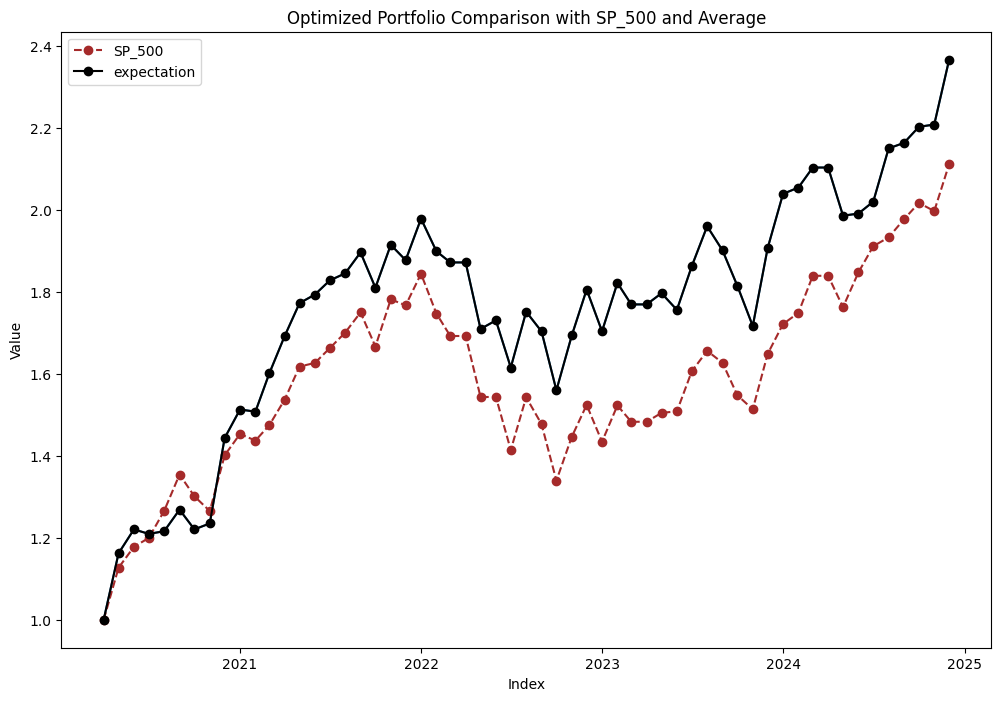

,Cumulative Return,Annualized Return,Observed Volatility,Downside Volatility,Sharpe,Sortino
SP_500,1.111558,0.173702,0.169474,0.099721,0.877114,1.490641
Optimized Portfolio,1.366446,0.202717,0.186666,0.095360,0.943014,1.845929


In [159]:
avg100 = final_visual()
oos1_list_spy = oos1_list.copy()
oos1_list_spy[0] = avg100
spy_performance_metrics = performance_metrics(avg100, .02692)
spy_performance_metrics

In [160]:
len(opt_portf_weights)

34

In [161]:
opt_portf_weights

,New Weights
Ticker,
AAPL,0.039909
ADP,0.006979
AMP,0.006476
AMZN,0.007493
AVGO,0.016653
BDX,0.024741
CB,0.038898
CHTR,0.023508
CLX,0.023966


In [164]:
rebalanced_optimal_weights()
rebalance_optimal_weights_appended

Ticker,A,AAPL,ABBV,ADBE,ADP,ADSK,AIZ,AKAM,ALB,AMAT,...,UNP,UPS,VMC,VRSK,VRSN,WAT,WHR,WM,WMT,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2020-04-01,0.000000,0.063944,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016756,0.000000,...,0.000000,0.023679,0.000000,0.000000,0.000000,0.000000,0.016770,0.000000,0.000000,0.000000
2020-05-01,0.000000,0.066230,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.019977,0.000000,...,0.000000,0.023873,0.000000,0.000000,0.000000,0.000000,0.017498,0.000000,0.000000,0.000000
2020-06-01,0.000000,0.074881,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.019862,0.000000,...,0.000000,0.026230,0.000000,0.000000,0.000000,0.000000,0.018334,0.000000,0.000000,0.000000
2020-07-01,0.000000,0.081965,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.019929,0.000000,...,0.000000,0.031642,0.000000,0.000000,0.000000,0.000000,0.021690,0.000000,0.000000,0.000000
2020-08-01,0.000000,0.024865,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021978,0.000000,...,0.000000,0.036237,0.000000,0.000000,0.000000,0.000000,0.023614,0.000000,0.000000,0.000000
2020-09-01,0.000000,0.022899,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.022124,0.000000,...,0.000000,0.037869,0.000000,0.000000,0.000000,0.000000,0.025073,0.000000,0.000000,0.000000
2020-10-01,0.000000,0.021674,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023258,0.000000,...,0.000000,0.035953,0.000000,0.000000,0.000000,0.000000,0.025393,0.000000,0.000000,0.000000
2020-11-01,0.000000,0.021249,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030415,0.000000,...,0.000000,0.035094,0.000000,0.000000,0.000000,0.000000,0.023951,0.000000,0.000000,0.000000
2020-12-01,0.000000,0.023127,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.032223,0.000000,...,0.000000,0.033735,0.000000,0.000000,0.000000,0.000000,0.021692,0.000000,0.000000,0.000000


In [ ]:
## RUSSELL 

In [165]:
spy_yoy_tickers1 = Russell_index

In [166]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1,0,.2,'rebalance','no')

2017
2021
441
Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True
Column 'TPL' could not be converted to float.
Column 'TPL' could not be converted to float.
2018
2022
446
Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'TPL' could not be converted to float.
True
2019
2023
455
Column 'TPL' could not be converted to float.
True
2020
2024
467
Column 'TPL' could not be converted to float.
True
2021
2024
477
True
2022
2024
480
True


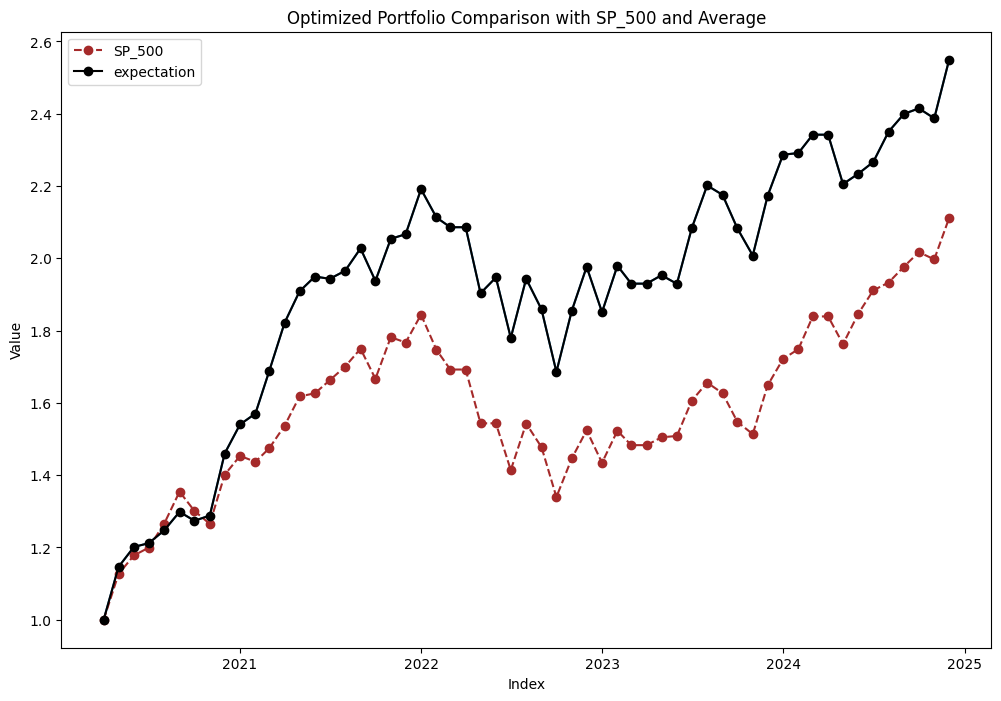

,Cumulative Return,Annualized Return,Observed Volatility,Downside Volatility,Sharpe,Sortino
SP_500,1.111558,0.173702,0.169474,0.099721,0.877114,1.490641
Optimized Portfolio,1.549556,0.222080,0.179648,0.097224,1.064542,1.967030


In [167]:
avg100 = final_visual()
oos1_list_russell = oos1_list.copy()
oos1_list_russell[0] = avg100
russell_performance_metrics = performance_metrics(avg100, .02692)
russell_performance_metrics

In [168]:
len(opt_portf_weights)

34

In [169]:
opt_portf_weights

,New Weights
Ticker,
AAPL,0.035251
ADP,0.019548
ALL,0.018500
AMAT,0.062103
AMD,0.002041
AVGO,0.031624
CHTR,0.064171
COIN,0.001038
CRWD,0.031097


In [170]:
rebalanced_optimal_weights()
rebalance_optimal_weights_appended

Ticker,AAPL,ABBV,ACN,ADBE,ADI,ADP,ALL,AMAT,AMD,AMGN,...,V,VRSN,VST,WAT,WDAY,WMT,WSM,WST,WYNN,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2020-04-01,0.021910,0.000000,0.000000,0.011120,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002277,0.000000
2020-05-01,0.022732,0.000000,0.000000,0.011655,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002126,0.000000
2020-06-01,0.025615,0.000000,0.000000,0.012888,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001867,0.000000
2020-07-01,0.028280,0.000000,0.000000,0.012465,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001720,0.000000
2020-08-01,0.008216,0.000000,0.000000,0.013782,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001988,0.000000
2020-09-01,0.007681,0.000000,0.000000,0.013715,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001700,0.000000
2020-10-01,0.007347,0.000000,0.000000,0.012724,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001745,0.000000
2020-11-01,0.007149,0.000000,0.000000,0.012115,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002154,0.000000
2020-12-01,0.007698,0.000000,0.000000,0.012234,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002337,0.000000


In [172]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1,0,0,'rebalance','no')

Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True
Column 'TPL' could not be converted to float.
Column 'TPL' could not be converted to float.
Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'TPL' could not be converted to float.
True
Column 'TPL' could not be converted to float.
True
Column 'TPL' could not be converted to float.
True
True
True


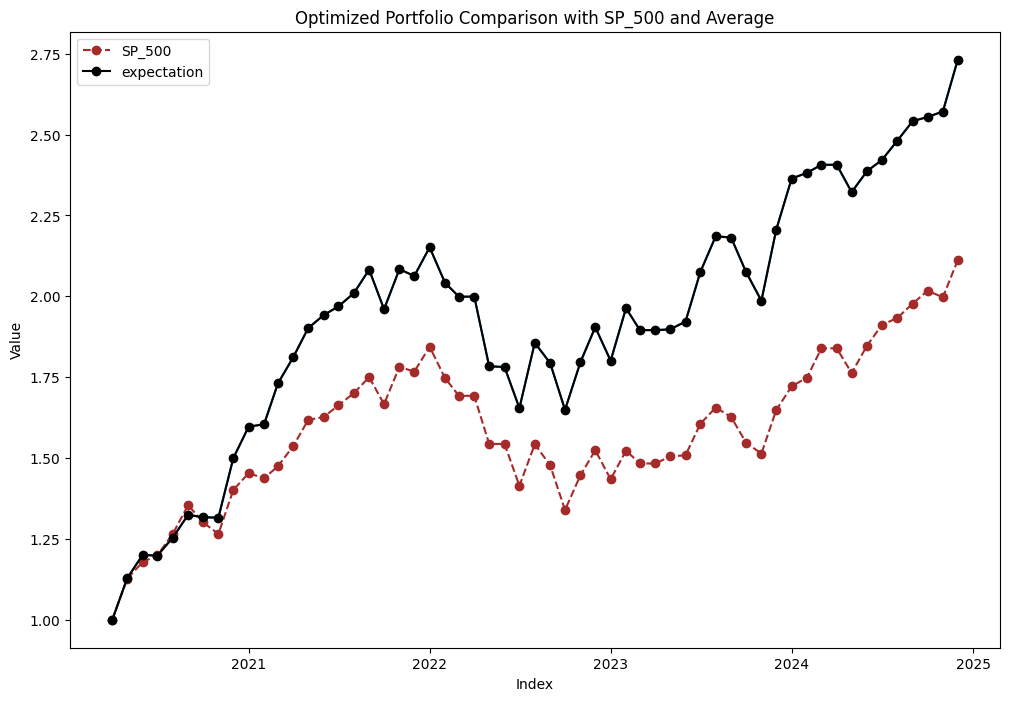

,SP_500,Optimized Portfolio
Date,,
2020-04-01,1.000000,1.000000
2020-05-01,1.126844,1.128101
2020-06-01,1.177870,1.199995
2020-07-01,1.199528,1.198448
2020-08-01,1.265624,1.253961
2020-09-01,1.354300,1.324514
2020-10-01,1.301173,1.316559
2020-11-01,1.265175,1.315840
2020-12-01,1.401239,1.499367


In [173]:
final_visual()

In [175]:
performance_metrics(oos1_list[0], .02692 )

,Cumulative Return,Annualized Return,Observed Volatility,Downside Volatility,Sharpe,Sortino
Ticker,,,,,,
SP_500,1.111558,0.173702,0.169474,0.099721,0.877114,1.490641
Optimized Portfolio,1.731451,0.240260,0.184283,0.096669,1.123545,2.141842


In [142]:
def rebalanced_optimal_weights():
    global rebalance_optimal_weights_appended
    output_years = oos1_list[0].index.year.unique().tolist()
    dfs = []
    rebalance_optimal_weights_appended = pd.DataFrame()
    
    for i, df_year in enumerate(rebalance_opt_weights[:len(output_years)]):
        df_temp = df_year.copy()
        df_temp.columns = [output_years[i]]  # Assign column names based on output years
        dfs.append(df_temp)

    df_final = pd.concat(dfs, axis=1).fillna(0)
    df_final.index = df_final.index.str[7:]
    df_final = df_final.T

    for i, year in enumerate(output_years):
        temp_df = optimal_weights_appended(pd.DataFrame(df_final.iloc[i]))   # type: ignore
        temp_df = temp_df.loc[temp_df.index.year == year]  # Filter by the current year
        rebalance_optimal_weights_appended = pd.concat([rebalance_optimal_weights_appended, temp_df])



In [163]:
def optimal_weights_appended(opt_port):  
    
    tickers_opt = opt_port.index.tolist()
    prices = pd.read_csv('daat.csv', parse_dates=['date'])
    prices.drop(columns='PERMNO', inplace=True)
    prices.drop(columns='RET', inplace=True)
    prices.rename(columns={'date': 'Date', 'TICKER': 'Ticker'}, inplace=True)
    prices.set_index('Date', inplace=True)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    prices = extract_stock_data(prices, opt_port.index.tolist(), start_date, end_date)
    
    # if value is NA, averages it with the before and after, as it would be too difficult to manually enter it if we scale up the use of this
    prices = prices.interpolate(method = 'linear', limit_direction = 'both') 
    base_prices = prices.iloc[0]
    holding_values = pd.DataFrame(index=prices.index, columns=prices.columns)
    for tickers_opt in prices.columns:
        weight_opt = opt_port.loc[tickers_opt].iloc[0]
        # (price / price_base) * initial_weight.
        holding_values[tickers_opt] = (prices[tickers_opt] / base_prices[tickers_opt]) * weight_opt

    # calc total portfolio value for each month.
    portfolio_value = holding_values.sum(axis=1)
    
    # normalize the values
    opt_portfolio_weights_appended = holding_values.div(portfolio_value, axis=0)
    return opt_portfolio_weights_appended

In [141]:
TLH_performance_metrics = TLH_performance_metrics.drop('SP_500')

In [142]:
TLH_performance_metrics.rename(index={"Optimized Portfolio": "Optimized Portfolio w/ TLH"}, inplace=True)
new_df = pd.concat([normal_performance_metrics, TLH_performance_metrics])
new_df

,Cumulative Return,Annualized Return,Observed Volatility,Downside Volatility,Sharpe,Sortino
SP_500,1.211178,0.147981,0.171451,0.111890,0.737622,1.130272
Optimized Portfolio,1.270066,0.153240,0.180312,0.110971,0.734862,1.194049
Optimized Portfolio w/ TLH,1.197779,0.146768,0.180794,0.112739,0.701980,1.125728


In [136]:
cccc = oos1_list_TLH[0].copy()

In [137]:
oos1_list_TLH[0].pop('Optimized Portfolio')

Date
2019-02-01    1.000000
2019-03-01    1.039621
2019-04-01    1.046304
2019-05-01    1.096977
2019-06-01    1.028048
                ...   
2024-08-01    1.932941
2024-09-01    2.022897
2024-10-01    2.049072
2024-11-01    2.029696
2024-12-01    2.197779
Name: Optimized Portfolio, Length: 70, dtype: float64

In [143]:
oos1_list_TLH[0].rename(index={"Optimized Portfolio": "Optimized Portfolio w/ TLH"}, inplace=True)

In [147]:
oos1_list

[Ticker        SP_500  Optimized Portfolio  Optimized Portfolio w/ TLH
 Date                                                                 
 2019-02-01  1.000000             1.000000                    1.000000
 2019-03-01  1.029729             1.039621                    1.029729
 2019-04-01  1.048186             1.046304                    1.048186
 2019-05-01  1.089393             1.096977                    1.089393
 2019-06-01  1.017735             1.028048                    1.017735
 ...              ...                  ...                         ...
 2024-08-01  2.024207             1.932941                    2.024207
 2024-09-01  2.070430             2.022897                    2.070430
 2024-10-01  2.112247             2.049072                    2.112247
 2024-11-01  2.091342             2.029696                    2.091342
 2024-12-01  2.211178             2.197779                    2.211178
 
 [70 rows x 3 columns]]

In [144]:
oos1_list[0]['Optimized Portfolio w/ TLH'] = oos1_list_TLH[0]

In [145]:
graph_df = oos1_list[0]

In [146]:
graph_df

Ticker,SP_500,Optimized Portfolio,Optimized Portfolio w/ TLH
Date,,,
2019-02-01,1.000000,1.000000,1.000000
2019-03-01,1.029729,1.039621,1.029729
2019-04-01,1.048186,1.046304,1.048186
2019-05-01,1.089393,1.096977,1.089393
2019-06-01,1.017735,1.028048,1.017735
...,...,...,...
2024-08-01,2.024207,1.932941,2.024207
2024-09-01,2.070430,2.022897,2.070430
2024-10-01,2.112247,2.049072,2.112247


In [ ]:

title = ' '
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(graph_df.index, graph_df['SP_500'], label='SP_500', linestyle='--',  markersize=8, markevery=12,color='red')
ax.plot(graph_df.index, graph_df['Optimized Portfolio'], label='expectation', markersize=8, markevery=12, color='black')
ax.plotgraph_df.index, graph_df['Optimized Portfolio w/ TLH'], label='expectation', markersize=8, markevery=12, color='grey')

ax.set_xlabel('Index')
ax.set_ylabel('Value')
ax.set_title(title)
ax.legend()
plt.show()


In [ ]:
TLH_2 = TLH_performance_metrics.drop('SP_500')
TLH_2.rename(index={"Optimized Portfolio": "Optimized Portfolio w/ TLH"}, inplace=True)
new_df = pd.concat([normal_performance_metrics, TLH_2])
new_df

2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
43

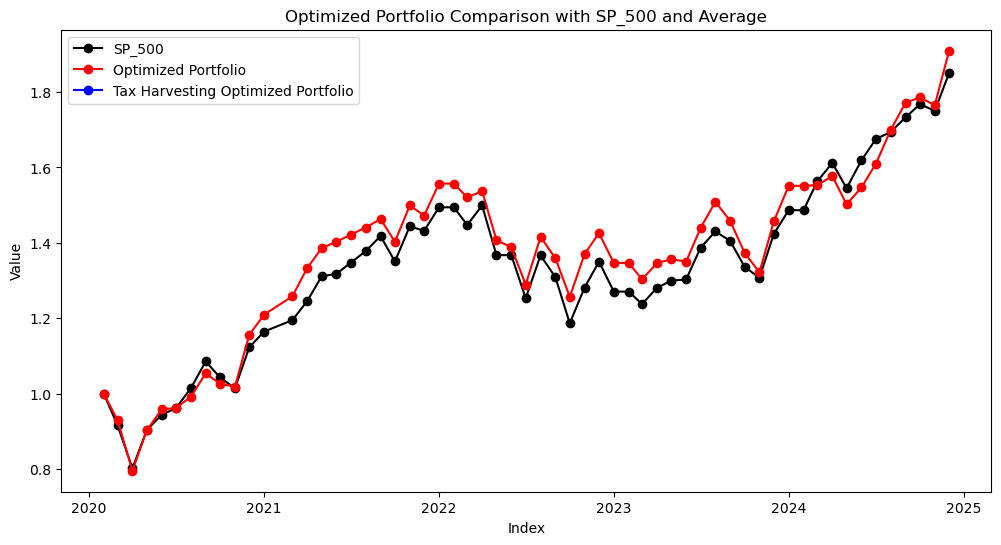

In [86]:

oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(6,0.9,0,0,'rebalance','TLH')
oos1_list_TLH = oos1_list.copy()
oos1_average_TLH = oos1_average.copy()
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(6,0.9,0,0,'rebalance','no')
oos1_list_TLH = [oos1_list_TLH.drop(columns=['SP_500'], errors='ignore') for oos1_list_TLH in oos1_list_TLH]
for i, df in enumerate(oos1_list_TLH):
    df.rename(columns={'Optimized Portfolio': f'oos1_list_TLH'}, inplace=True)

### GRAPH

fig, ax = plt.subplots(figsize=(12, 6))
#    for i, df in enumerate(oos1_list):
#         ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
#ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
last_df_index = oos1_list[-1].index
concatenated_df = pd.concat(oos1_list, axis=1)
concatenated_df1= pd.concat(oos1_list_TLH, axis=1)
averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
averaged_df_C = concatenated_df1.filter(like='Optimized Portfolio').mean(axis=1)

averaged_df = pd.DataFrame({
    'SP_500': averaged_df_A,
    'Optimized Portfolio': averaged_df_B,
     'Tax Harvesting Optimized Portfolio': averaged_df_C
})
ax.plot(averaged_df.index, averaged_df['SP_500'], label='SP_500', marker='o', color='black')
ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='Optimized Portfolio', marker='o', color='red')
ax.plot(averaged_df.index, averaged_df['Tax Harvesting Optimized Portfolio'],label='Tax Harvesting Optimized Portfolio', marker='o', color='blue')

ax.set_xlabel('Index')
ax.set_ylabel('Value')
ax.set_title('Optimized Portfolio Comparison with SP_500 and Average')
ax.legend()
plt.show()




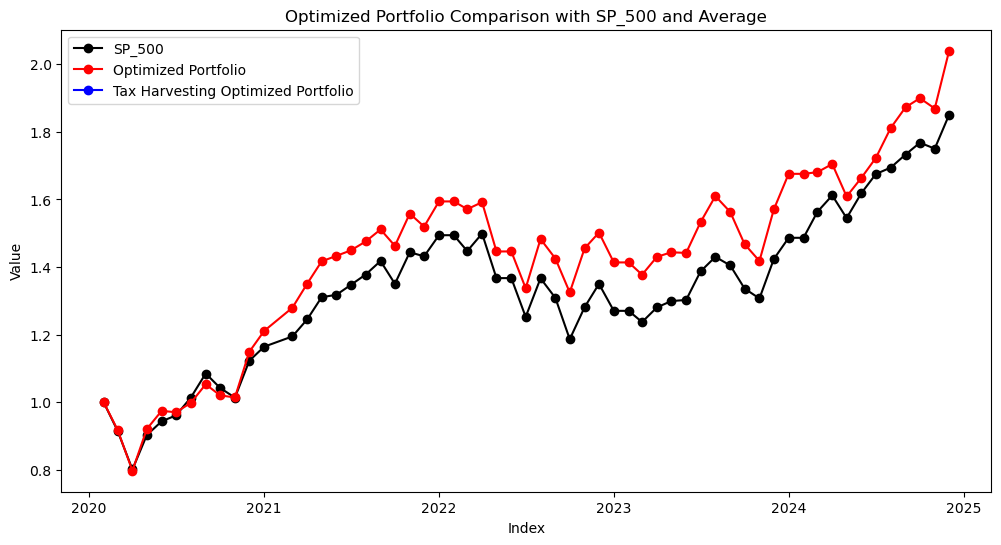

In [66]:

fig, ax = plt.subplots(figsize=(12, 6))
#    for i, df in enumerate(oos1_list):
#         ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
#ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
last_df_index = oos1_list[-1].index
concatenated_df = pd.concat(oos1_list, axis=1)
concatenated_df1= pd.concat(oos1_list_TLH, axis=1)
averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
averaged_df_C = concatenated_df1.filter(like='Optimized Portfolio').mean(axis=1)

averaged_df = pd.DataFrame({
    'SP_500': averaged_df_A,
    'Optimized Portfolio': averaged_df_B,
     'Tax Harvesting Optimized Portfolio': averaged_df_C
})
ax.plot(averaged_df.index, averaged_df['SP_500'], label='SP_500', marker='o', color='black')
ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='Optimized Portfolio', marker='o', color='red')
ax.plot(averaged_df.index, averaged_df['Tax Harvesting Optimized Portfolio'],label='Tax Harvesting Optimized Portfolio', marker='o', color='blue')

ax.set_xlabel('Index')
ax.set_ylabel('Value')
ax.set_title('Optimized Portfolio Comparison with SP_500 and Average')
ax.legend()
plt.show()



In [51]:
import os

class AdaptiveBandit:
    def __init__(self, target_years=5, objective='max_return'):
        self.target_years = target_years
        self.objective = objective.lower()
        self.best_combination = np.array([1.0, 0, 0])
        self.best_return = -np.inf
        self.storage_file = f"explored_{self.objective}.csv"
        self.explored = self.load_explored_combinations()
    def load_explored_combinations(self):
        if os.path.exists(self.storage_file):
            df = pd.read_csv(self.storage_file)
            df[['c1', 'c2', 'c3', 'reward']] = df[['c1', 'c2', 'c3', 'reward']].astype(float)
            return df
        return pd.DataFrame(columns=['c1', 'c2', 'c3', 'reward'])


    def save_combination(self, combination, reward):
        new_entry = pd.DataFrame([{
            'c1': combination[0],
            'c2': combination[1],
            'c3': combination[2],
            'reward': reward
        }])
        self.explored = pd.concat([self.explored, new_entry], ignore_index=True)
        self.explored.to_csv(self.storage_file, index=False)
    def save_combination(self, combination, reward):
        combination = np.array(combination, dtype=float)
        reward = float(reward)
        new_entry = pd.DataFrame([{
            'c1': combination[0],
            'c2': combination[1],
            'c3': combination[2],
            'reward': reward
        }])
        self.explored = pd.concat([self.explored, new_entry], ignore_index=True)
        self.explored.to_csv(self.storage_file, index=False)
    def save_combination(self, combination, reward):
        combination = self.round_combination(combination)
        reward = float(reward)
    
        if self.check_existing_combination(combination) is not None:
            return  # Skip if already saved

        new_entry = pd.DataFrame([{
            'c1': combination[0],
            'c2': combination[1],
            'c3': combination[2],
            'reward': reward
        }])
        self.explored = pd.concat([self.explored, new_entry], ignore_index=True)
        self.explored.to_csv(self.storage_file, index=False)



    def check_existing_combination(self, combination):
        combination = self.round_combination(combination)
        match = self.explored[
            (self.explored['c1'] == combination[0]) &
            (self.explored['c2'] == combination[1]) &
            (self.explored['c3'] == combination[2])
        ]
        if not match.empty:
            return match.iloc[0]['reward']
        return None

    def round_combination(self, combination):
        return np.round(np.array(combination, dtype=float), 1)



    def evaluate_combination(self, beta_combination):
        betaa = beta_combination[0]
        betab = beta_combination[1]
        betac = beta_combination[2]
        oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,betaa, betab, betac,'rebalance','TLH')
        if self.objective == 'max_return':
            simulated_df = sp_final_visual()
        else:
            simulated_df = get_consistently_worst_portfolio(oos1_list, 'Optimized Portfolio')
        return simulated_df

    def reward_function(self, simulated_df):
        if self.objective in ['downside_protection']:
            returns_spy = simulated_df['SP_500'].pct_change().dropna()
            downside_returns_spy = returns_spy[returns_spy < 0]  
            downside_vol_spy = np.sqrt((downside_returns_spy ** 2).mean()) * np.sqrt(12)

            returns_opt = simulated_df['Optimized Portfolio'].pct_change().dropna()
            downside_returns_opt = returns_opt[returns_opt < 0]  
            downside_vol_opt = np.sqrt((downside_returns_opt ** 2).mean()) * np.sqrt(12)
            
            reward = downside_vol_spy/downside_vol_opt
            return reward

        returns = simulated_df['Optimized Portfolio'].pct_change().dropna()
        if self.objective == 'sharpe':
            return returns.mean() / returns.std() if returns.std() != 0 else -np.inf
        
        elif self.objective == 'sortino':
            
            returns_spy = simulated_df['SP_500'].pct_change().dropna()
            downside_returns_spy = returns_spy[returns_spy < 0]  
            downside_vol_spy = np.sqrt((downside_returns_spy ** 2).mean()) * np.sqrt(12)

            returns_opt = simulated_df['Optimized Portfolio'].pct_change().dropna()
            downside_returns_opt = returns_opt[returns_opt < 0]  
            downside_vol_opt = np.sqrt((downside_returns_opt ** 2).mean()) * np.sqrt(12)
            
            mean_spy = returns_spy.mean()*12
            mean_opt = returns_opt.mean()*12
            
            spy_sortino = mean_spy/downside_vol_spy
            opt_sortino = mean_opt/downside_vol_opt
            reward = opt_sortino/spy_sortino
            
            return reward
        else:
            raise ValueError(f"Unknown objective: {self.objective}")

    # def explore_direction(self, base_combination):
    #     candidates = []
    #     directions = [-0.1, 0.1]
    #     lower_bounds = np.array([0.9, 0.0, 0.0])
    #     upper_bounds = np.array([2.3, 2.2, 2.2])
    
    #     for i in range(3):
    #         for delta in directions:
    #             new_combination = base_combination.copy()
    #             new_combination[i] += delta
    #             new_combination = np.clip(new_combination, lower_bounds, upper_bounds)

    #             existing = self.check_existing_combination(new_combination)
    #             if existing is not None:
    #                 reward = existing
    #             else:
    #                 simulated_df = self.evaluate_combination(new_combination)
    #                 reward = self.reward_function(simulated_df)
    #                 self.save_combination(new_combination, reward)

    #             candidates.append((new_combination, reward))

    #     return candidates
    def explore_direction(self, base_combination):
        candidates = []
        directions = [-0.1, 0.2]
        lower_bounds = np.array([0.9, 0.0, 0.0])
        upper_bounds = np.array([2.3, 2.2, 2.2])
        found_new = False

        for i in range(3):
            for delta in directions:
                new_combination = base_combination.copy()
                new_combination[i] += delta
                new_combination = np.clip(new_combination, lower_bounds, upper_bounds)

                if self.check_existing_combination(new_combination) is not None:
                    continue  # Already explored, skip it

                new_combination = np.round(new_combination, 1)
                simulated_df = self.evaluate_combination(new_combination)
                reward = self.reward_function(simulated_df)
                self.save_combination(new_combination, reward)
                candidates.append((new_combination, reward))
                found_new = True
        

        return candidates, found_new



    # def select_next_combination(self):
    #     candidates = self.explore_direction(self.best_combination)

    # # Filter only those with unseen combinations (i.e., actually evaluated)
    #     new_explorations = [c for c in candidates if self.check_existing_combination(c[0]) is None]

    # # If all are previously explored, still pick the best for possible updates
    #     candidates.sort(key=lambda x: x[1], reverse=True)
    #     best_candidate, best_reward = candidates[0]

    #     was_new = best_candidate in [c[0] for c in new_explorations]

    #     if best_reward > self.best_return:
    #         self.best_combination = best_candidate
    #         self.best_return = best_reward

    #     return self.best_combination, was_new
    def select_next_combination(self):
        candidates, found_new = self.explore_direction(self.best_combination)

        if not candidates:
            return self.best_combination, False  # No new exploration found

        candidates.sort(key=lambda x: x[1], reverse=True)
        best_candidate, best_reward = candidates[0]

        if best_reward > self.best_return:
            self.best_combination = best_candidate
            self.best_return = best_reward

        return self.best_combination, found_new
    def run_bandit(self, iterations=3, initializer='yes'):
        print(f"Running bandit optimization for objective: '{self.objective}'")

    # Base initialization
        if initializer == 'yes':
            base = np.array([1.0, 0, 0])
        else:
            if not self.explored.empty:
                best_row = self.explored.loc[self.explored['reward'].idxmax()]
                base = np.array([best_row['c1'], best_row['c2'], best_row['c3']])
            else:
                print("No previous data found. Using default base combination.")
                base = np.array([1.0, 0, 0])

    # Evaluate base combo
        reward = self.check_existing_combination(base)
        if reward is None:
            simulated_df = self.evaluate_combination(base)
            reward = self.reward_function(simulated_df)
            self.save_combination(base, reward)

        self.best_combination = base
        self.best_return = reward

        print(f"Base Combination: {self.best_combination}, Base Score: {self.best_return:.4f}")

        valid_iterations = 0
        attempt_cap = iterations*10  # Avoid infinite loops

        while valid_iterations < iterations and attempt_cap > 0:
            new_combination, found_new = self.select_next_combination()
            attempt_cap -= 1

            if found_new:
                valid_iterations += 1
                print(f"[{valid_iterations}] New Combo: {new_combination} → Score: {self.best_return:.4f}")
            else:
                print("No new combination found. Expanding search...")

            # Optional: add random direction or noise when stuck
                random_combo = self.best_combination + np.random.uniform(-0.2, 0.2, size=3)
                random_combo = np.clip(random_combo, [0.9, 0.0, 0.0], [2.3, 2.2, 2.2])

                if self.check_existing_combination(random_combo) is None:
                    simulated_df = self.evaluate_combination(random_combo)
                    reward = self.reward_function(simulated_df)
                    self.save_combination(random_combo, reward)

                    if reward > self.best_return:
                        self.best_combination = random_combo
                        self.best_return = reward
                        valid_iterations += 1
                        print(f"[{valid_iterations}] Random Exploration: {random_combo} → Score: {self.best_return:.4f}")

        print("\nFinal Best Combination:")
        print(f"{self.best_combination} → Score: {self.best_return:.4f}")

    
    # def run_bandit(self, iterations=50, initializer='yes'):
    #     print(f"Running bandit optimization for objective: '{self.objective}'")

    # # Determine the base combination
    #     if initializer == 'yes':
    #         base = np.array([1.0, 0.0, 0.0])
    #     else:
    #         if not self.explored.empty:
    #             best_row = self.explored.loc[self.explored['reward'].idxmax()]
    #             base = np.array([best_row['c1'], best_row['c2'], best_row['c3']])
    #         else:
    #             print("No previous data found. Falling back to default base combination.")
    #             base = np.array([1.0, 0.0, 0.0])

    # # Evaluate base
    #     reward = self.check_existing_combination(base)
    #     if reward is None:
    #         simulated_df = self.evaluate_combination(base)
    #         reward = self.reward_function(simulated_df)
    #         self.save_combination(base, reward)
    
    #     self.best_combination = base
    #     self.best_return = reward

    #     print(f"Base Combination: {self.best_combination}, Base Score ({self.objective}): {self.best_return:.4f}")

    #     valid_iterations = 0
    #     max_attempts = iterations * 3  # Prevent infinite loop

    #     while valid_iterations < iterations and max_attempts > 0:
    #         new_combination, was_new = self.select_next_combination()
    #         max_attempts -= 1

    #         if was_new:
    #             valid_iterations += 1
    #             print(f"Iteration {valid_iterations}, Best Combination: {new_combination}, Best Score ({self.objective}): {self.best_return:.4f}")
    #         else:
    #             print(f"Skipped already explored combination: {new_combination}")

    #     print("\nFinal Best Combination Found:")
    #     print(f"Best Combination: {self.best_combination}, Best Score ({self.objective}): {self.best_return:.4f}")






In [52]:
def get_consistently_worst_portfolio(dfs, portfolio_col='portfolio'):
    """
    Returns the DataFrame whose portfolio is consistently the worst performer.

    Parameters:
        dfs (list of pd.DataFrame): Each must have a 'portfolio' and 'sp500' column.
        portfolio_col (str): The portfolio column name.

    Returns:
        pd.DataFrame: The worst performing portfolio's full DataFrame.
    """

    # Extract portfolio series and align them
    portfolio_series_list = [df[portfolio_col] for df in dfs]

    # Get the common index (intersection of all time indices)
    common_index = set(portfolio_series_list[0].index)
    for series in portfolio_series_list[1:]:
        common_index &= set(series.index)
    common_index = sorted(common_index)

    # Reindex all series to the common index
    aligned_series = [s.loc[common_index] for s in portfolio_series_list]

    # Combine into a single DataFrame and give column names as their list indices
    combined_portfolios = pd.concat(aligned_series, axis=1)
    combined_portfolios.columns = list(range(len(dfs)))  # [0, 1, 2, ...]

    # Count how often each column has the minimum value across rows
    min_indices = combined_portfolios.idxmin(axis=1)
    min_counts = min_indices.value_counts()

    # Find the column (index) that was the minimum most often
    worst_index = min_counts.idxmax()

    # Return the corresponding original DataFrame
    return dfs[worst_index]

In [53]:
bandit = AdaptiveBandit(objective='sortino')  # or 'max_return', 'sortino', etc.
bandit.run_bandit(iterations=100)


Running bandit optimization for objective: 'sortino'
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
Base Combination: [1. 0. 0.], Base Score: 1.0482
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
[1] New Combo: [1.  0.  0.2] → Score: 1.1018
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
True
2020
2024
415
True
2021
2024
433
True
2022
2024
450
True
2017
2021
380
True
2018
2022
386
True
2019
2023
400
Tru

: 

In [ ]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(3,1.0,0,0.2,'rebalance',3,5,stop)
avg_1 = final_visual() #()
final_visual() 
performance_metrics(avg_1, .02692)
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(3,1.2,0.1,0.3,'rebalance',3,10,stop)
avg_2 = final_visual() #()
final_visual() 
performance_metrics(avg_2, .02692)
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(3,0.9,0.1,0.1,'rebalance',3,5,stop)
avg_3 = final_visual() #()
final_visual() 
performance_metrics(avg_3, .02692)
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(3,0.9,0.2,0.3,'rebalance',3,5,stop)
avg_4 = final_visual() #()
final_visual() 
performance_metrics(avg_4, .02692)
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(3,0.9,0.5,0.4,'rebalance',3,10,stop)
avg_5 = final_visual() #()
final_visual() 
performance_metrics(avg_5, .02692)
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(3,0.9,0.5,0.3,'rebalance',3,5,stop)
avg_6 = final_visual() #()
final_visual() 
performance_metrics(avg_6, .02692)



Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'INVH' could not be converted to float.
True
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/sishengliang/opt/anaconda3/envs/newquant/lib/python3.9/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/yn/_rglt16j18j_1p61vqk0b68w0000gn/T/0c3389ba3fca4c3a8779be1882acad85-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/yn/_rglt16j18j_1p61vqk0b68w0000gn/T/0c3389ba3fca4c3a8779be1882acad85-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2301 COLUMNS
At line 41482 RHS
At line 43779 BOUNDS
At line 44224 ENDATA
Problem MODEL has 2296 rows, 2256 columns and 38256 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0004I processed model has 962 rows, 1365 columns (443 integer (443 of which b

In [60]:
oos1_list

[Ticker        SP_500  Optimized Portfolio
 Date                                     
 2020-02-01  1.000000             1.000000
 2020-03-01  0.915890             0.915727
 2020-04-01  0.801295             0.747073
 2020-05-01  0.902934             0.871296
 2020-06-01  0.943821             0.903611
 2020-07-01  0.961176             0.915398
 2020-08-01  1.014138             0.942984
 2020-09-01  1.085193             1.002789
 2020-10-01  1.042623             0.960361
 2020-11-01  1.013778             0.973190
 2020-12-01  1.122806             1.144754
 2021-01-01  1.164485             1.208106
 2021-03-01  1.194868             1.267980
 2021-04-01  1.245577             1.351822
 2021-05-01  1.310876             1.412821
 2021-06-01  1.318069             1.424986
 2021-07-01  1.347349             1.431142
 2021-08-01  1.377998             1.462301
 2021-09-01  1.417946             1.487794
 2021-10-01  1.350496             1.409288
 2021-11-01  1.443875             1.503946
 2021-12-01

In [61]:
oos1_average_TLH

{2: 1.5454946663334805,
 3: 1.3837160446292955,
 4: 1.6667388186643213,
 5: 1.9869237972862324}

In [62]:
oos1_average

{2: 1.5446187814254408,
 3: 1.3530980490709896,
 4: 1.653835996203039,
 5: 1.9608312034826534}

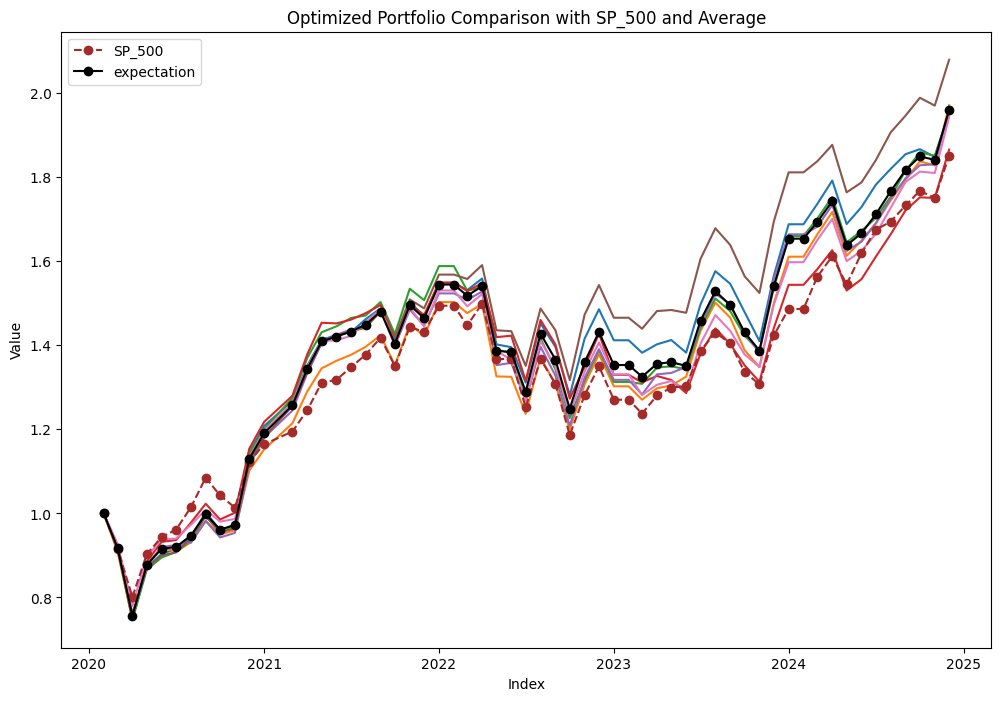

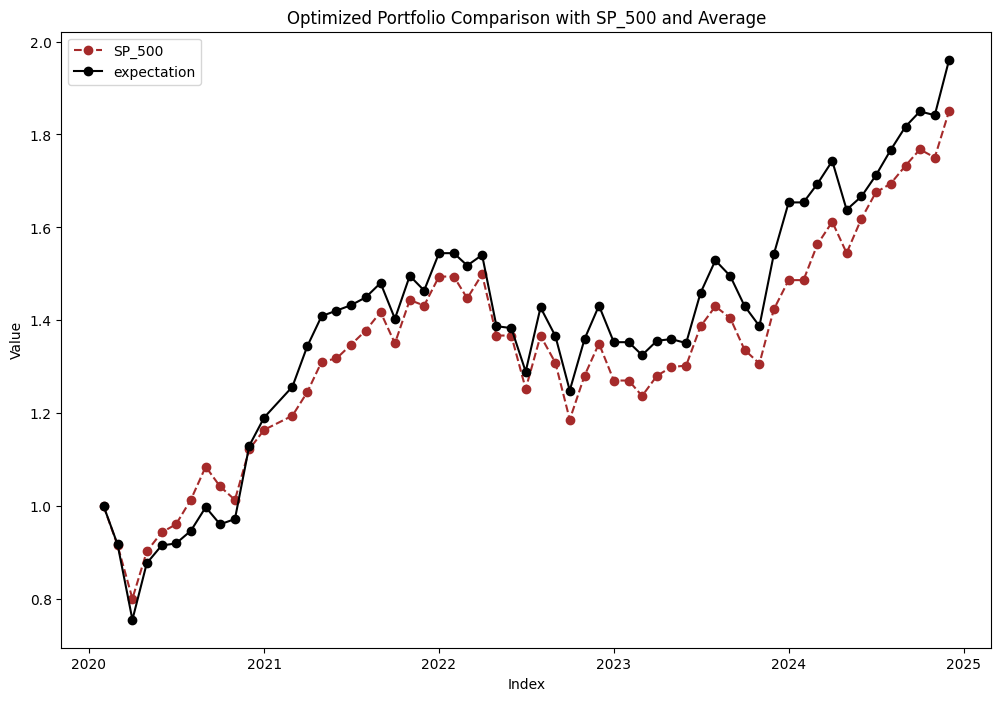

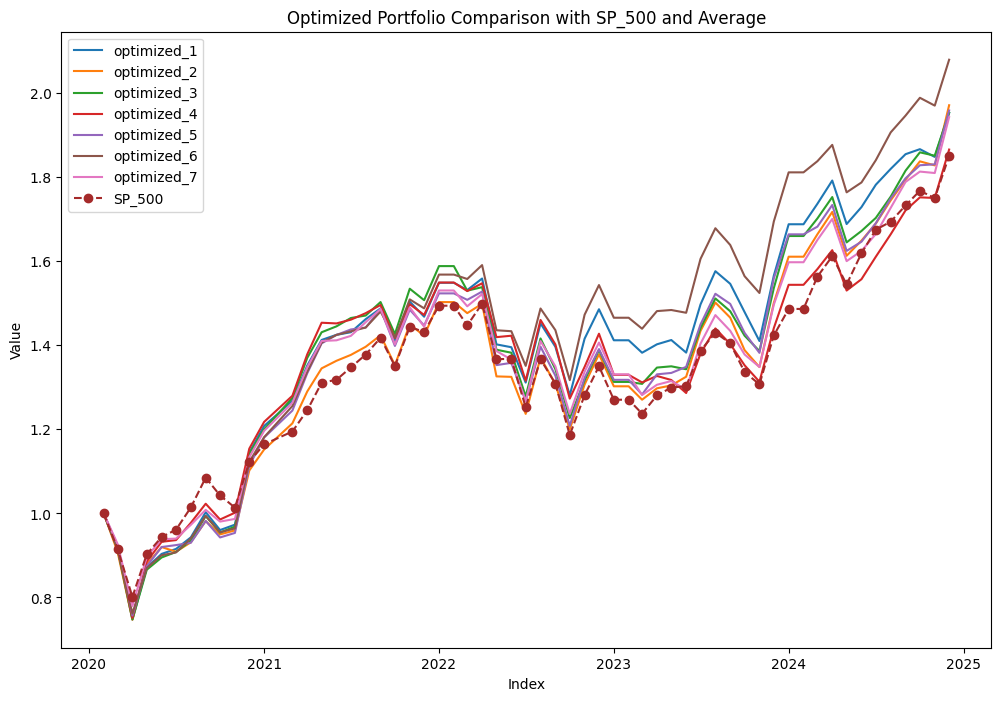

,SP_500,Optimized Portfolio
Date,,
2020-02-01,1.000000,1.000000
2020-03-01,0.915890,0.917908
2020-04-01,0.801295,0.755927
2020-05-01,0.902934,0.877502
2020-06-01,0.943821,0.915710
2020-07-01,0.961176,0.920087
2020-08-01,1.014138,0.947280
2020-09-01,1.085193,0.997995
2020-10-01,1.042623,0.961251


In [63]:
# TAX LOSS HARVESTING
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100

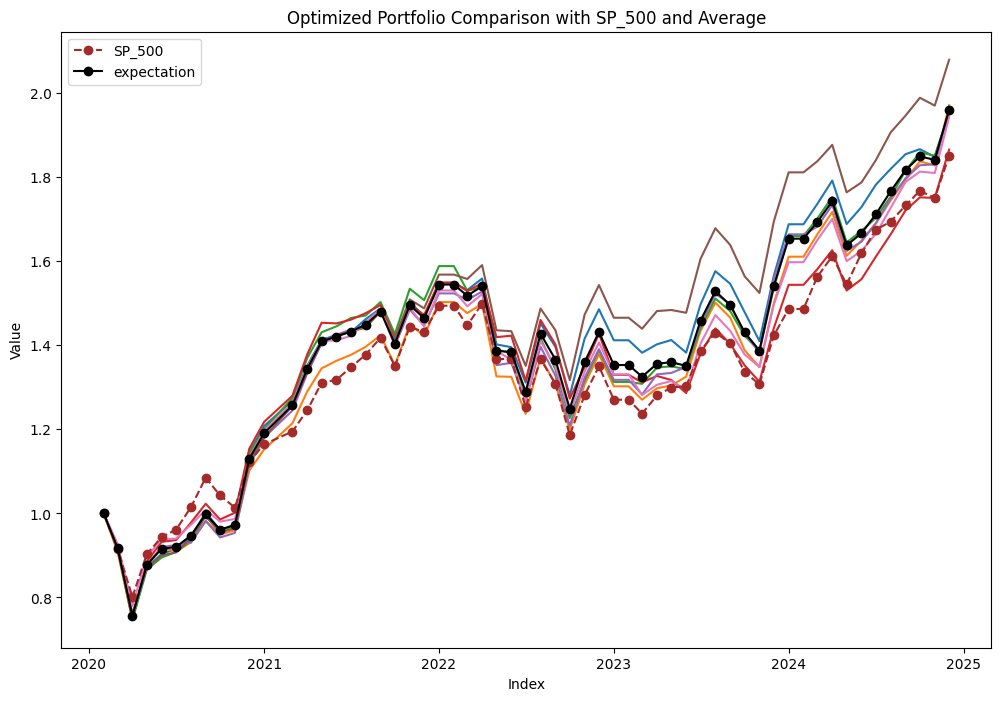

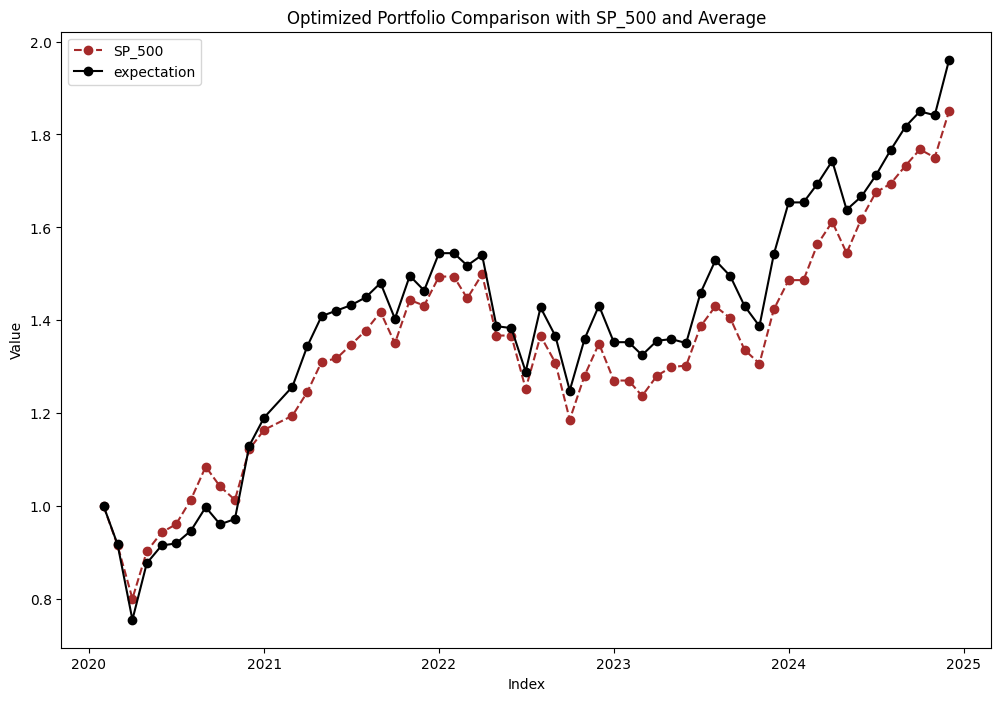

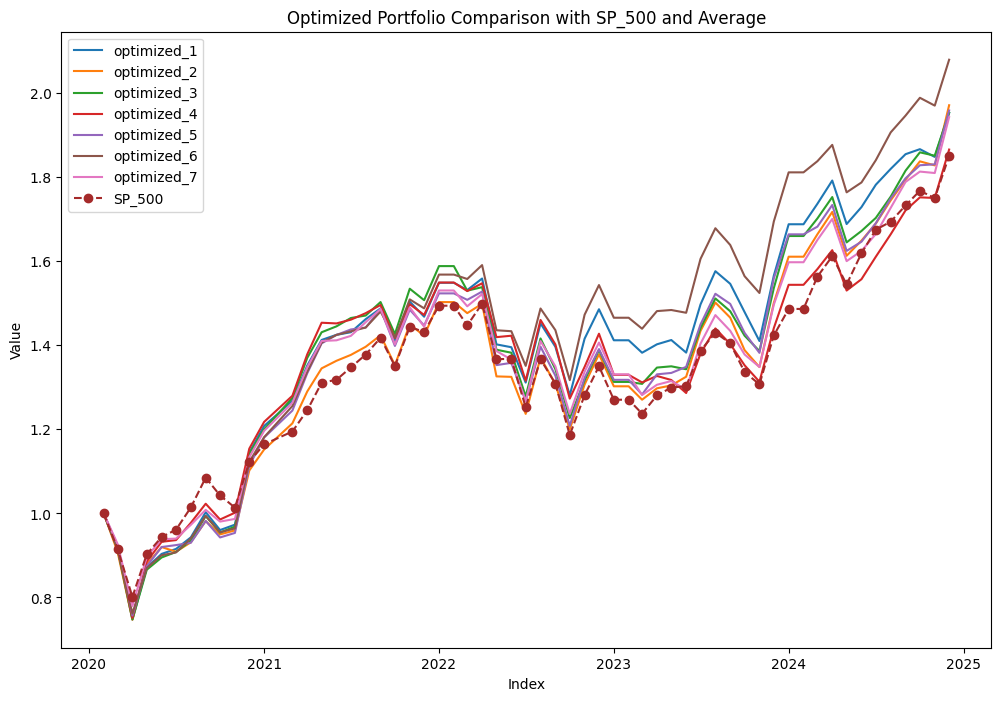

,SP_500,Optimized Portfolio
Date,,
2020-02-01,1.000000,1.000000
2020-03-01,0.915890,0.917908
2020-04-01,0.801295,0.755927
2020-05-01,0.902934,0.877502
2020-06-01,0.943821,0.915710
2020-07-01,0.961176,0.920087
2020-08-01,1.014138,0.947280
2020-09-01,1.085193,0.997995
2020-10-01,1.042623,0.961251


In [64]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100

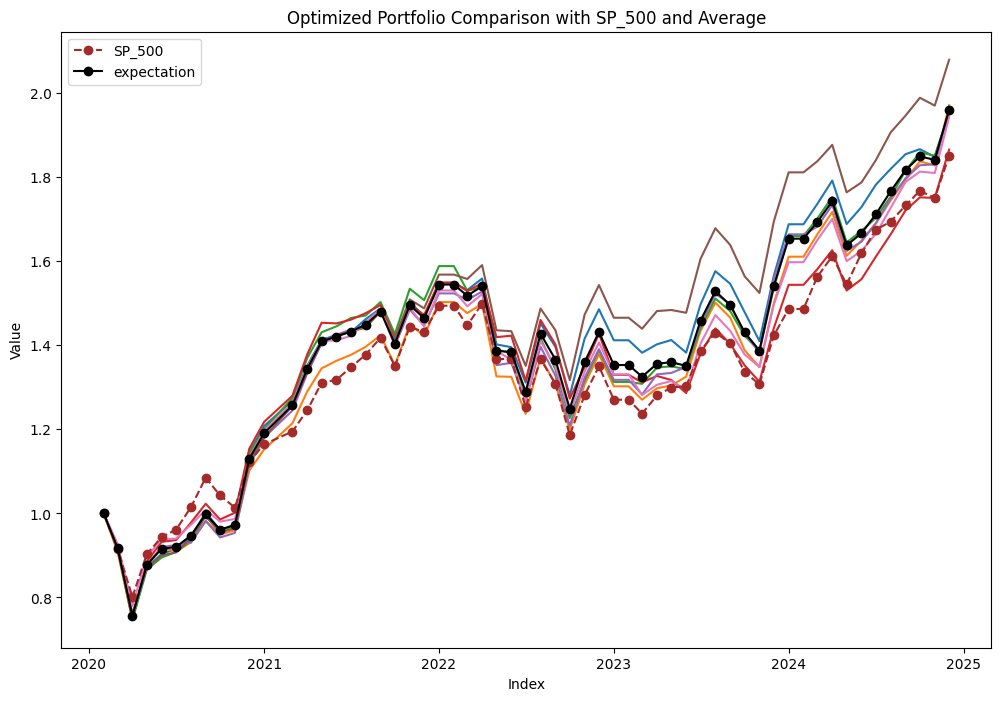

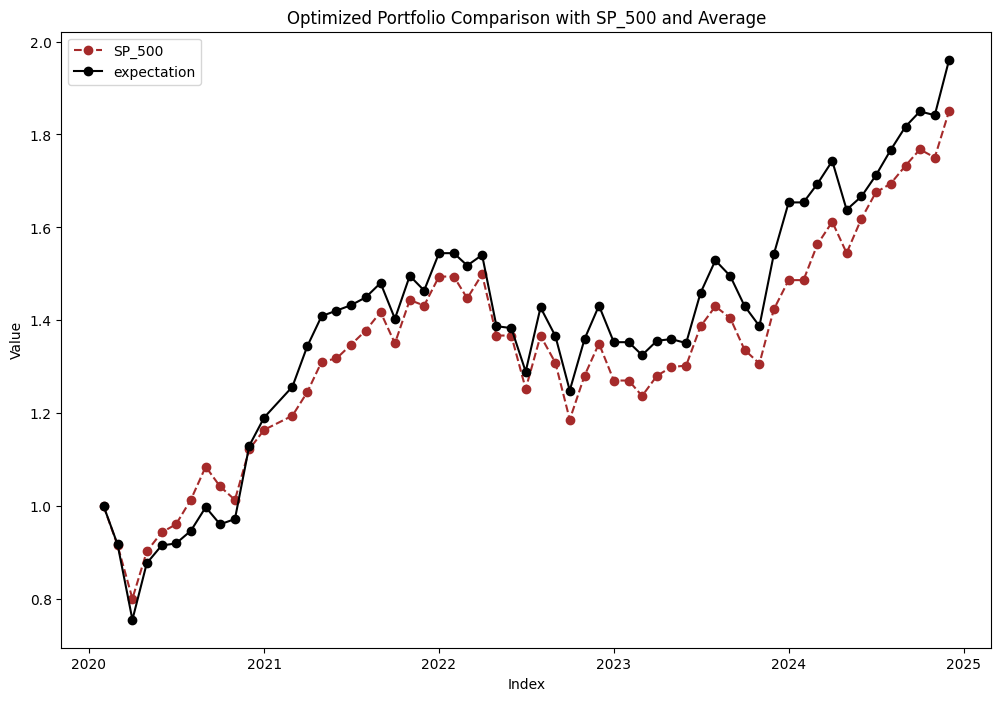

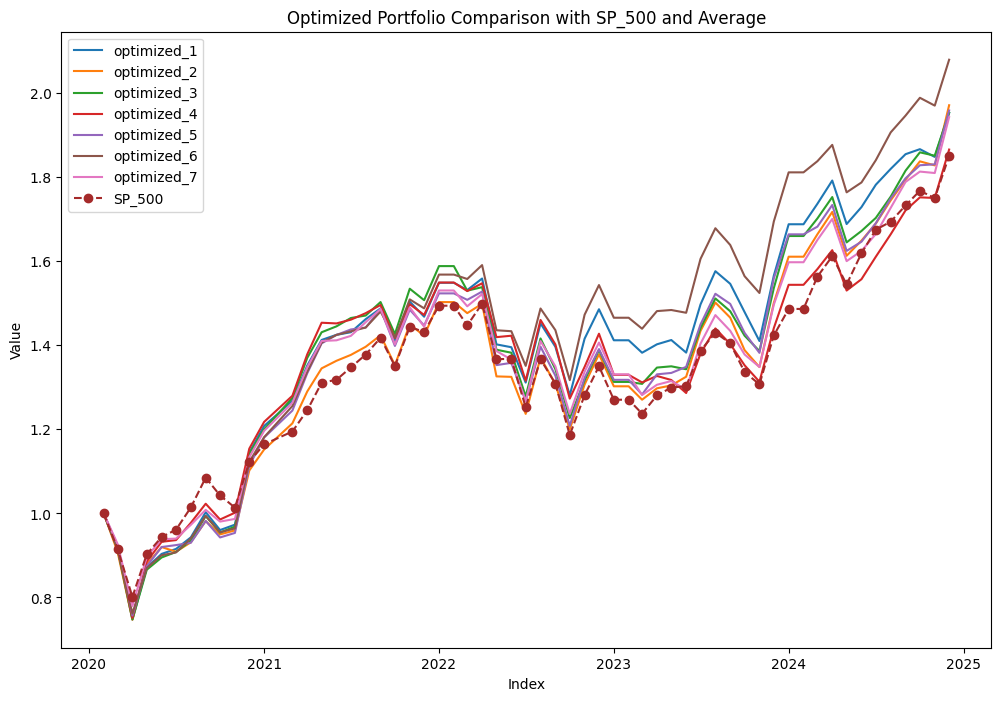

,SP_500,Optimized Portfolio
Date,,
2020-02-01,1.000000,1.000000
2020-03-01,0.915890,0.917908
2020-04-01,0.801295,0.755927
2020-05-01,0.902934,0.877502
2020-06-01,0.943821,0.915710
2020-07-01,0.961176,0.920087
2020-08-01,1.014138,0.947280
2020-09-01,1.085193,0.997995
2020-10-01,1.042623,0.961251


In [65]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100

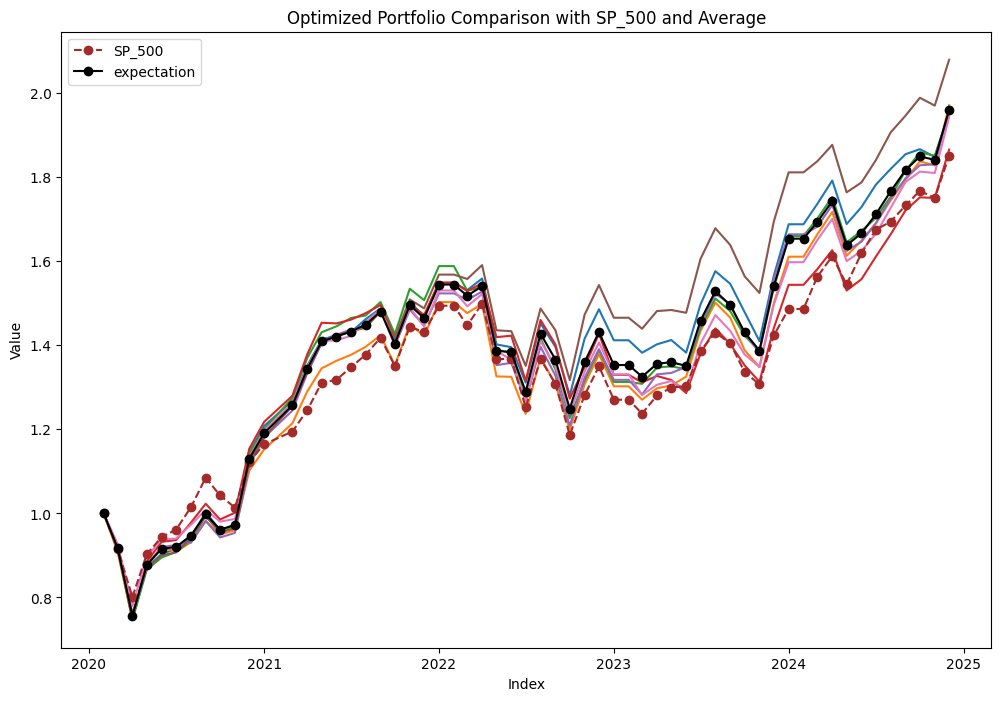

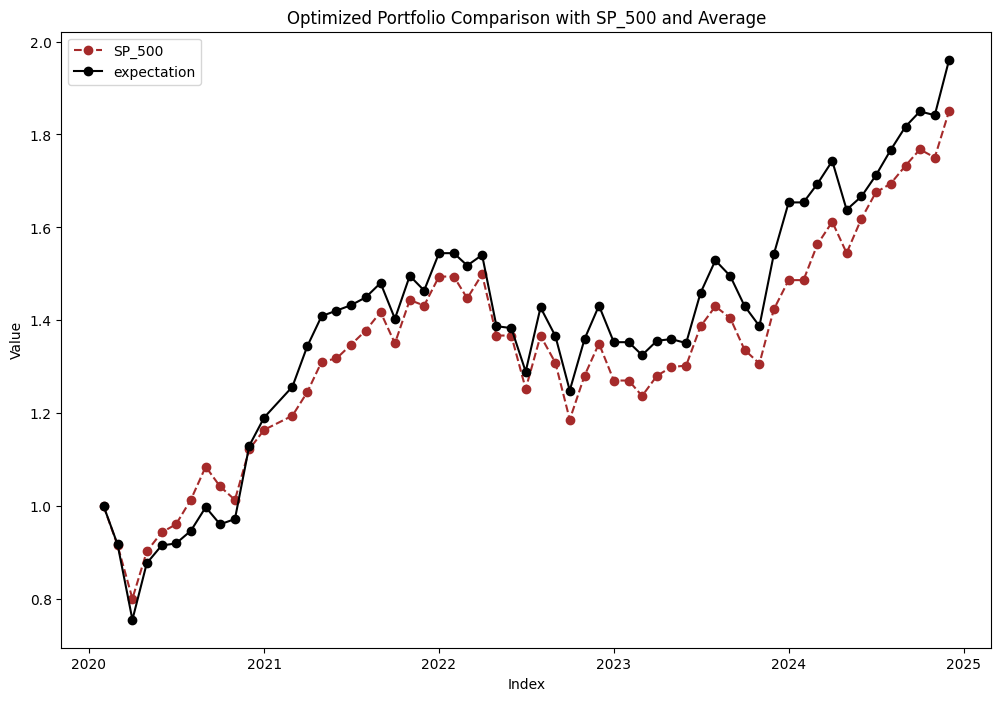

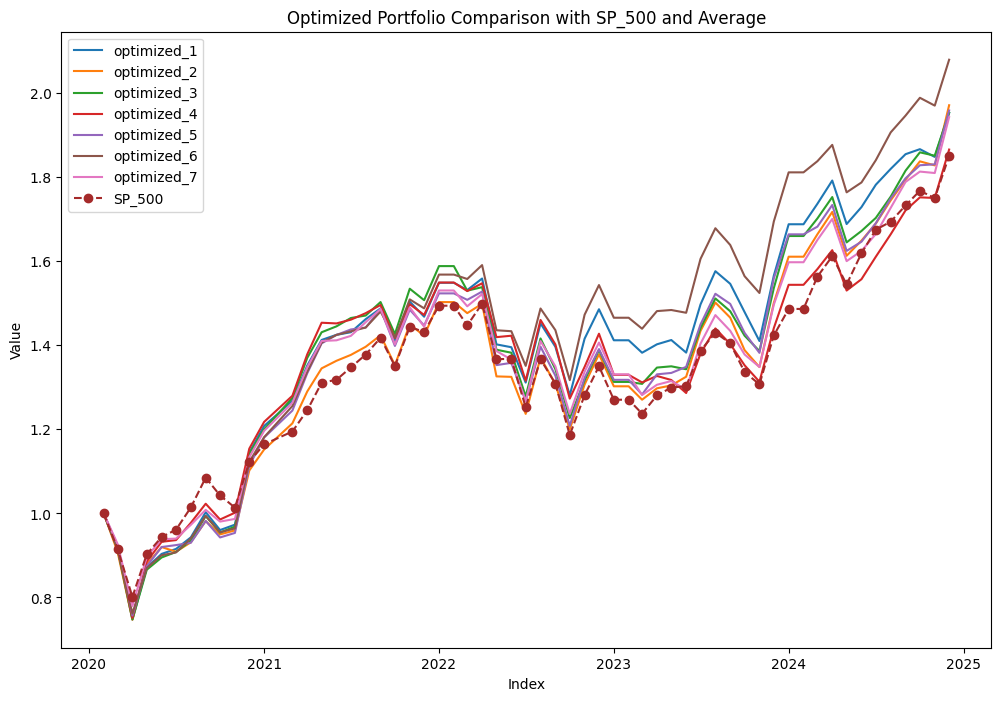

,SP_500,Optimized Portfolio
Date,,
2020-02-01,1.000000,1.000000
2020-03-01,0.915890,0.917908
2020-04-01,0.801295,0.755927
2020-05-01,0.902934,0.877502
2020-06-01,0.943821,0.915710
2020-07-01,0.961176,0.920087
2020-08-01,1.014138,0.947280
2020-09-01,1.085193,0.997995
2020-10-01,1.042623,0.961251


In [66]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100

In [67]:
flist={}
cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')
print(cumulative_exp_return)
print(sim_one_percentile)
save_df_with_combination_to_excel(sim_one_percentile,'combination_data.xlsx','downside_protection',[1,0,0],2,0,0)
flist['100 rebalance']=avg_100
yoy_exp_return

KeyError: Timestamp('2021-02-01 00:00:00')

In [ ]:
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')

In [ ]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(22,1,0,0,'no')

In [ ]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100


In [ ]:

cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')
print(cumulative_exp_return)
print(sim_one_percentile)
save_df_with_combination_to_excel(sim_one_percentile,'combination_data.xlsx','downside_protection',[1,0,0],11,0,0)
flist['100']=avg_100
yoy_exp_return

In [ ]:
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')


In [ ]:
finale_visual(flist)

# Saving analysis to excel sheet

In [ ]:
from openpyxl import Workbook
workbook_filename = 'combination_data.xlsx'
wb = Workbook()
wb.save(workbook_filename)


In [ ]:
save_df_with_combination_to_excel(sim_one_percentile,workbook_filename,'downside_protection',[1,0.75,0.5],0,0,0)

In [ ]:
save_df_with_combination_to_excel(gdsk,workbook_filename,'downside_protection',['SP500','SP500','SP500'],1,0,0)

In [ ]:
save_df_with_combination_to_excel(sim_one_percentile,workbook_filename,'downside_protection',[1,0.5,0.5],2,0,0)

# Error checking area

In [ ]:
simulator(1,0,0,n_year_before,out_of_sample_year_end[2],upatebudget,50)
sjijas=out_of_sampless(out_of_sample_year_start[3],out_of_sample_year_end[3])
tostorelist.append(sjijas)
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000


In [ ]:
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000

In [ ]:
simulator(1,0,0,n_year_before,n_year_after,1000000,50)
sjijas=out_of_sampless(out_of_sample_year_start[1],out_of_sample_year_end[1])
tostorelist.append(sjijas)
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000


In [ ]:
upatebudget

In [ ]:
out_of_sample_year_end[2]

In [ ]:
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

def estimate_rolling_ff3_betas(stock_weights, factors, window): #stock_weightshts is opt_portf_weights appended or not, factros is ff3 monthly, window is number of months used in regression analysis
    # creates roll_betas df with equal allignment 
    stocks = stock_weights.columns
    factors_list = ['Intercept', 'Mkt-RF', 'SMB', 'HML']
    multi_cols = pd.MultiIndex.from_product([stocks, factors_list], names=['Stock', 'Factor'])
    rolling_betas = pd.DataFrame(index=stock_weights.index, columns=multi_cols, dtype=float)
    
    # runs rolling regression for ff3 betas
    for stock in stocks:
        # y variable: stock excess returns
        y = stock_weights[stock] - factors['RF'] 
        # X variables: Mkt-RF, SMB, HML (plus intercept)
        X = sm.add_constant(factors[['Mkt-RF', 'SMB', 'HML']], has_constant='add')  
        rolling_model = RollingOLS(y, X, window=window)
        rolling_result = rolling_model.fit()

        # const get converted to intercept
        rolling_params = rolling_result.params.rename(columns={'const': 'Intercept'}) # intercept is the same as RF in port_betas fnct

        # indexes to match rolling_betas index
        rolling_params = rolling_params.reindex(rolling_betas.index)

        # Assigns each factor's rolling betas to rolling_betas df to use for different timeframes
        for factor in factors_list:
            if factor in rolling_params.columns: 
                rolling_betas.loc[:, (stock, factor)] = rolling_params[factor].to_numpy()
    rolling_betas = rolling_betas*100
    return rolling_betas
# For refrence, the intercept (alpha) in this case is a constant for the regression models, it is effecitvely the 
# the excess return for a risk free rate.

In [ ]:
def optimal_weights_appended(opt_port):
    tickers_opt = opt_port.index.tolist()
    prices = yf.download(tickers_opt, start=oos1_new_performance.index[0],end=oos1_new_performance.index[-1],interval="1mo")['Adj Close']
    
    # if value is NA, averages it with the before and after, as it would be too difficult to manually enter it if we scale up the use of this
    prices = prices.interpolate(method = 'linear', limit_direction = 'both') 
    base_prices = prices.iloc[0]
    holding_values = pd.DataFrame(index=prices.index, columns=prices.columns)
    for tickers_opt in prices.columns:
        weight_opt = opt_port.loc[tickers_opt].iloc[0]
        # (price / price_base) * initial_weight.
        holding_values[tickers_opt] = (prices[tickers_opt] / base_prices[tickers_opt]) * weight_opt

    # calc total portfolio value for each month.
    portfolio_value = holding_values.sum(axis=1)
    
    # normalize the values
    opt_portfolio_weights_appended = holding_values.div(portfolio_value, axis=0)
    return opt_portfolio_weights_appended

In [ ]:
def get_portfolio_betas_for_date(date, opt_portfolio_weights_appended, i):
    if isinstance(date, str):
        date = datetime.strptime(date, "%Y-%m-%d")
    if date > oos1_new_performance.index[5]:
        opt_portfolio_weights_appended = optimal_weights_appended(opt_portfolio_weights_appended)
        weights_opt = opt_portfolio_weights_appended.loc[date]
        rolling_betas = estimate_rolling_ff3_betas(opt_portfolio_weights_appended, ff3_monthly, i) 
        # grab the single row for the given date
        row = rolling_betas.loc[date]  
        factor_level = rolling_betas.columns.levels[1]
        
        # build a dict of factor exposures
        portfolio_factor_exposures = {}
        
        for factor in factor_level:
            # weighted sum of each ticker's factor betas
            total_factor_beta = 0.0
            for ticker, w in weights_opt.items():
                beta_value = row[(ticker, factor)]
                total_factor_beta += w * beta_value
    
            portfolio_factor_exposures[factor] = total_factor_beta
        final_df_betas = pd.Series(portfolio_factor_exposures, name=date)
        return pd.concat([final_df_betas.iloc[2:], final_df_betas.iloc[:2]]).iloc[:-1] # reindexes to match the usual order and drops intercept row
    else:
        print("Error, needs 6 months to run rolling window analysis")

In [ ]:
def monthly_beta_change(i, futures_df):
    # so you input the index you start at first (i) and it returns a data frame of each the difference of each 3 factors for the next month 
    # this approach makes it so you can add the options to be considered into the ff3 differnces to compare and use w/o figures
    
    opt_portf_index = opt_portf_weights #opt_portfolio_weights.loc[oos1_new_performance.index[i]]# I was incorrectly using opt_portf_weights for months that arent the first month, so instead I can pull that month from the M/M weights. 
    
    ff3_df_start = get_portfolio_betas_for_date(oos1_new_performance.index[i], opt_portf_index, i)
    opt_portf_weights_appended = pd.concat([opt_portf_index, futures_df])
    if futures_df.empty:
        opt_portf_weights_appended = opt_portf_index.copy()
    else:
        opt_portf_weights_appended = pd.concat([opt_portf_index, futures_df])
        opt_portf_weights_appended["New Weights"] = opt_portf_weights_appended["New Weights"] / opt_portf_weights_appended["New Weights"].abs().sum()
    ff3_df_end = get_portfolio_betas_for_date(oos1_new_performance.index[i+1], opt_portf_weights_appended, i+1)   

    return ff3_df_end, ff3_df_start # i dont know if ff3_df_start has any benefit?

In [ ]:
def get_fama_by_q():
    ff3_quarters = gff.famaFrench3Factor(frequency='m')
    ff3_quarters.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
    ff3_quarters['Date'] = pd.to_datetime(ff3_quarters['Date'])
    ff3_quarters.set_index('Date', inplace=True)
    ff3_quarters.sort_index(inplace=True)
    ff3_quarterly = ff3_quarters.resample('Q').mean()

    # Resample the quarterly data to monthly frequency by forward-filling
    return ff3_quarters.loc[oos1_new_performance.index]

# Ill keep this incase we want to hedge by quarters, as this works as a base case for ff3 regression


In [ ]:
def get_dynamic_multiplier(futures_prices, future_ticker, desired_notional_exposure):
    current_price = futures_prices.loc[future_ticker]
    multiplier = desired_notional_exposure / current_price
    return abs(multiplier.item())

In [ ]:
# similar to hedge_portoflio_function, jsut written for all 3 factros and specific indexes
def calculate_futures_positions(current_betas, optimal_betas, portfolio_value, futures_prices, EOM_futures_prices, default_contract_multipliers, desired_notional_exposures, dynamic_tickers, i):
    
    # compute beta differences for each factor:
    delta_MKT = (optimal_betas['Mkt-RF'] - current_betas['Mkt-RF'])
    delta_SMB = (optimal_betas['SMB'] - current_betas['SMB'])
    delta_HML = (optimal_betas['HML'] - current_betas['HML'])
    
    positions = []
    scale_factor = 10 # this is an aproach- not perfect (somewhat of a short term fix), if I rework exposure it may noy be neccessary  
    def get_multiplier(ticker):
        # checks if index is held constant or not
        if ticker in dynamic_tickers:
            return get_dynamic_multiplier(futures_prices, ticker, desired_notional_exposures[ticker])
        else:
            return default_contract_multipliers[ticker] 

    # Market factor: ES=F
    pos_MKT = "LONG" if delta_MKT > 0 else ("SHORT" if delta_MKT < 0 else "NO ACTION")
    mult_MKT = get_multiplier("ES=F")
    contracts_MKT = (abs(delta_MKT * portfolio_value) / (futures_prices.loc["ES=F"] * mult_MKT)
                     if mult_MKT > 0 else 0)
    if round(contracts_MKT.item(),0) == 0:
        pos_MKT = "NO ACTION"
        
    positions.append({
        "ETF Name": "ES=F",
        "Position": pos_MKT,
        "Number of Contracts": round(contracts_MKT, 0).item(),
        "Cost of Contracts ($)": round(futures_prices.loc["ES=F"]*mult_MKT *round(contracts_MKT, 0),2).item()/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["ES=F"]*mult_MKT *round(contracts_MKT, 0),2).item()/scale_factor,
        "Multiplier": round(mult_MKT,2)
    })
    
    # SMB factor:
    # IWM (small-cap) follows the sign of delta_SMB.
    pos_IWM = "LONG" if delta_SMB > 0 else ("SHORT" if delta_SMB < 0 else "NO ACTION")
    mult_IWM = get_multiplier("IWM")
    contracts_IWM = (abs(delta_SMB * portfolio_value) / (futures_prices.loc["IWM"] * mult_IWM)
                     if mult_IWM > 0 else 0)
    if round(contracts_IWM.item(),0) == 0:
        pos_IWM = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWM",
        "Position": pos_IWM,
        "Number of Contracts": round(contracts_IWM, 0).item(),
        "Cost of Contracts ($)": round(futures_prices.loc["IWM"]*mult_IWM *round(contracts_IWM, 0),2).item()/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWM"]*mult_IWM *round(contracts_IWM, 0),2).item()/scale_factor,
        "Multiplier": mult_IWM
    })
    
    # IWB (large-cap) takes the opposite signal of delta_SMB.
    pos_IWB = "SHORT" if delta_SMB > 0 else ("LONG" if delta_SMB < 0 else "NO ACTION")
    mult_IWB = get_multiplier("IWB")
    contracts_IWB = (abs(delta_SMB * portfolio_value) / (futures_prices.loc["IWB"] * mult_IWB)
                     if mult_IWB > 0 else 0)
    if round(contracts_IWB.item(),0) == 0:
        pos_IWB = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWB",
        "Position": pos_IWB,
        "Number of Contracts": round(contracts_IWB, 0).item(),
        "Cost of Contracts ($)": round(futures_prices.loc["IWB"]*mult_IWB *round(contracts_IWB, 0),2).item()/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWB"]*mult_IWB *round(contracts_IWB, 0),2).item()/scale_factor,
        "Multiplier": mult_IWB
    })
    
    # HML factor:
    # IWD (value) follows the sign of delta_HML.
    pos_IWD = "LONG" if delta_HML > 0 else ("SHORT" if delta_HML < 0 else "NO ACTION")
    mult_IWD = get_multiplier("IWD")
    contracts_IWD = (abs(delta_HML * portfolio_value) / (futures_prices.loc["IWD"] * mult_IWD)
                     if mult_IWD > 0 else 0)
    if round(contracts_IWD.item(),0) == 0:
        pos_IWD = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWD",
        "Position": pos_IWD,
        "Number of Contracts": round(contracts_IWD, 0).item(),
        "Cost of Contracts ($)": round(futures_prices.loc["IWD"]*mult_IWD *round(contracts_IWD, 0), 2).item()/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWD"]*mult_IWD *round(contracts_IWD, 0), 2).item()/scale_factor,
        "Multiplier": mult_IWD
         })
    
    # IWF (growth) takes the opposite signal of delta_HML.
    pos_IWF = "SHORT" if delta_HML > 0 else ("LONG" if delta_HML < 0 else "NO ACTION")
    mult_IWF = get_multiplier("IWF")
    contracts_IWF = (abs(delta_HML * portfolio_value) / (futures_prices.loc["IWF"] * mult_IWF)
                     if mult_IWF > 0 else 0)
    if round(contracts_IWF.item(),0) == 0:
        pos_IWF = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWF",
        "Position": pos_IWF,
        "Number of Contracts": round(contracts_IWF, 0).item(),
        "Cost of Contracts ($)": round(futures_prices.loc["IWF"]*mult_IWF *round(contracts_IWF, 0), 2).item()/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWF"]*mult_IWF *round(contracts_IWF, 0),2).item()/scale_factor,
        "Multiplier": mult_IWF
    })

    return pd.DataFrame(positions, columns=["ETF Name", "Position", "Number of Contracts", "Cost of Contracts ($)", "EOM Value ($)"]) # WILL DELETE THE /10
    

In [ ]:
def compute_optimal_exposure(change_in_betas, prices, future_ff3_factors):
    # function plugs the matrix of a solver into the formula B*w = delta (desired change in portfolio's factor exposure)
 
    df_factors = future_ff3_factors.unstack(level='Factor')
    # df_factors now has columns [Intercept, Mkt-RF, SMB, HML], indexed by [ES=F, IWB, IWD, IWF, IWM]

    # drop the 'Intercept' column
    df_factors = df_factors[['Mkt-RF', 'SMB', 'HML']]  # keep only the 3 factors

    df_factors = df_factors.reindex(prices.index)

    #    Rows = factors, columns = 
    factors = ['Mkt-RF', 'SMB', 'HML']
    c_matrix = df_factors[factors].T.values  # shape: (3, 5)

    # we want to refactor it to a difference of 0 between target and current betas, so 0.0 for all 3:
    delta_vec = np.array([
        change_in_betas.get('Mkt-RF', 0.0),
        change_in_betas.get('SMB',    0.0),
        change_in_betas.get('HML',    0.0)
    ])

    #    B * w = delta_vec
    #    w = # of SHARES for each ticker
    w, residuals, rank, s = np.linalg.lstsq(c_matrix, delta_vec, rcond=None)
    prices = prices["Prices"]
    #w = w.flatten()
    
    df_result = pd.DataFrame({
        "Shares": w,
        "Price": prices,
    }, index=df_factors.index)

    # Notional = how many shares * price per share
    df_result["Notional"] = df_result["Shares"] * df_result["Price"]

    return df_result


In [ ]:
# need function to calculate p/l of the hedging 
def calc_hedging_pl(hedge_df):

    # computes the change in value, profit if stocks goes up and is LONG, and loss if stock goes up and is SHORT - vice versa 
    hedge_df["P/L ($)"] = hedge_df.apply(
        lambda row: (row["EOM Value ($)"] - row["Cost of Contracts ($)"])
        if row["Position"] == "LONG" else
        (row["Cost of Contracts ($)"] - row["EOM Value ($)"]),
        axis=1
    )

    # computes +- change relative to total value of futures, because the amounts are not constant 
    total_cost = hedge_df["Cost of Contracts ($)"].sum()
    hedge_df["P/L (%)"] = hedge_df.apply(
        lambda row: (row["P/L ($)"] / total_cost * 100)
        if row["Cost of Contracts ($)"] != 0 else 0,
        axis=1
    )

    hedge_df["P/L ($)"] = hedge_df["P/L ($)"].round(2)
    hedge_df["P/L (%)"] = hedge_df["P/L (%)"].round(2)
    
    return hedge_df

In [ ]:
future_data = pd.read_csv('daat.csv')
future_data.set_index('TICKER', inplace=True)
future_data=future_data[['date','PRC']]
future_data

In [ ]:
end1 = oos1_list[0].index[-1]
start1 = oos1_list[0].index[0]

MKT_RF_futures = future_data.loc['SPY']
MKT_RF_futures.set_index('date', inplace=True)

# Pre Process to average NAs with last and next month, contracts do get redownloaded, but this method is used as well-
MKT_RF_futures = MKT_RF_futures.interpolate(method='linear', limit_direction='both')
MKT_RF_futures = MKT_RF_futures.loc[start1:end1]
print(MKT_RF_futures)

In [ ]:
oos1_list[0]

In [ ]:
o1_end_d


In [ ]:
# # REWRITE, MKT-RF - SMB - HML, SP_500  & RUSSELL FUTURES TO ACHIEVE OPTIMIZED HEDGING, using monthly futures for now.
from IPython.display import display
famafrenchreturns()

end1 = o1_end_d
start1 = oos1_new_performance.index[0]
#MKT-RF futures
MKT_RF_futures1 = yf.download("ES=F",start=start1,end=end1,interval='1mo')['Adj Close']

# Pre Process to average NAs with last and next month, contracts do get redownloaded, but this method is used as well-
MKT_RF_futures = MKT_RF_futures1.reindex(start1)
MKT_RF_futures = MKT_RF_futures.interpolate(method = 'linear', limit_direction = 'both')

#SMB futures- # this is subject to change
L_R2000F_small_cap = yf.download("IWM",start=start1,end=end1,interval='1mo')['Adj Close']
L_R2000F_small_cap = L_R2000F_small_cap.interpolate(method = 'linear', limit_direction = 'both') 

S_R1000F_large_cap = yf.download("IWB",start=start1,end=end1,interval='1mo')['Adj Close']
S_R1000F_large_cap = S_R1000F_large_cap.interpolate(method = 'linear', limit_direction = 'both') 

s_1 = pd.Series(L_R2000F_small_cap)
s_2 = pd.Series(S_R1000F_large_cap)


#HML futures- # this is subject to change
L_R1000F_value = yf.download("IWD",start=start1,end=end1,interval='1mo')['Adj Close']
L_R1000F_value = L_R1000F_value.interpolate(method = 'linear', limit_direction = 'both') 

S_R1000F_growth = yf.download("IWF",start=start1,end=end1,interval='1mo')['Adj Close']
S_R1000F_growth = S_R1000F_growth.interpolate(method = 'linear', limit_direction = 'both') 

h_1 = pd.Series(L_R1000F_value)
h_2 = pd.Series(S_R1000F_growth)


# combine the 3 dfs to have a total future df
total_futures_df = pd.concat([MKT_RF_futures,s_1, s_2, h_1, h_2], axis= 1).dropna()

#leaving out the minmum variance hedge ratio, but will add it if needed- I wasnt using it in my quarter simulator


#prepares all optimal values from port_betas
#0- MKT, 1- SMB, 2-HML 
betas_target = pd.Series({'Mkt-RF': port_betas.iloc[0][1], 'SMB': port_betas.iloc[1][1], 'HML': port_betas.iloc[2][1]}) # if we want this to change and be dyanimc, we can put in the loop and change M/M

print("Target Beta Values")
display(betas_target)

total_future_pl = 0
#Simulator for 12 months: 
for i in range (6,7):#6-18 for full year):
    
    start_1 = oos1_new_performance.index[i] # must start at the 7th month of trading, as 6 months is needed for regression analysis
    #end1 = 
    betas_current = pd.Series((get_portfolio_betas_for_date(start_1, opt_portf_weights,i)))

    # print("Size of each contract being hedged")
    print("Current Beta Values: ")
    display(pd.DataFrame(betas_current))
    
    print("Difference of Beta Values: ")
    betas_difference = betas_current - betas_target
    display(pd.DataFrame(betas_difference))
    
    future_prices = total_futures_df.iloc[i]
    future_prices = pd.DataFrame({"Prices": [future_prices.iloc[0], future_prices.iloc[1], future_prices.iloc[2],future_prices.iloc[3], future_prices.iloc[4]]}, index=["ES=F", "IWM", "IWB", "IWD", "IWF"])
    EOM_future_prices = total_futures_df.iloc[i+1]
    EOM_future_prices = pd.DataFrame({"Prices": [EOM_future_prices.iloc[0], EOM_future_prices.iloc[1], EOM_future_prices.iloc[2],EOM_future_prices.iloc[3], EOM_future_prices.iloc[4]]}, index=["ES=F", "IWM", "IWB", "IWD", "IWF"])
    # total value of the 5 futures
    F = (future_prices.sum()).item() 

    beta_multiplier = F #B * oos1_new_performance.loc['start1'][1] , maybe?
    nototional_exposure = compute_optimal_exposure(betas_difference*beta_multiplier, future_prices, estimate_rolling_ff3_betas(optimal_weights_appended(future_prices), ff3_monthly, i).iloc[i])
    # need to touch up this function 
    
    #print(nototional_exposure)
    default_contract_multipliers = { "ES=F": 1000, "IWM": 100, "IWB": 100, "IWD": 100, "IWF": 100} # I may try some of these constant 
    dynamic_tickers = {"IWM", "IWB", "IWD", "IWF", "ES=F"} 
    hedge_df = calculate_futures_positions(betas_current, betas_target, B, future_prices, EOM_future_prices, default_contract_multipliers, nototional_exposure.iloc[:,2], dynamic_tickers, i)
    hedge_df = hedge_df.set_index("ETF Name")
    #display(hedge_df)
    hedge_df = calc_hedging_pl(hedge_df)
    display(hedge_df)
    total_future_pl += hedge_df['P/L ($)'].sum()
    
    # Next part is calculating the futures difference on the ff3 betas. The startegy is adding the 5 tickers of futures to opt_portf_weights, with Long contracts being postive and Short negative. 
    # Pre processing/ index matching opt_portf_weights and the future weights 
    
    position_cost_df = hedge_df[["Position", "Cost of Contracts ($)"]].copy()
    position_cost_df["Cost of Contracts ($)"] = position_cost_df.apply(
        lambda row: -row["Cost of Contracts ($)"] if row["Position"] == "SHORT" else row["Cost of Contracts ($)"],
        axis=1
    )
    
    future_weights = position_cost_df.drop(columns=["Position"])
    future_weights["Cost of Contracts ($)"] = future_weights["Cost of Contracts ($)"] /  (B * oos1_new_performance.loc['start_1'][1])
    
    
    future_weights.index = future_weights.index.astype(str)
    future_weights = future_weights.rename(columns={'Cost of Contracts ($)': 'New Weights'})
    future_weights = future_weights.rename_axis("Ticker")

    ff3_df_eom_no_futures = pd.Series((get_portfolio_betas_for_date(oos1_new_performance.index[i+1], opt_portf_weights, i+1)))
    ff3_df_eom_w_futures, ff3_df_start = monthly_beta_change(i, future_weights) 
    print("EOM Fama-French betas WITHOUT futures considered: ")
    display(ff3_df_eom_no_futures)
    print("EOM Fama-French betas WITH futures considered: ")
    display(ff3_df_eom_w_futures)
    print("Difference of betas Fama-French with futures considered vs without futures: ")
    print("\n\n\n")
print(f'Total P/L ($) for all futures: ${total_future_pl:.2f}')
